## Section 1 â€” Setup & Data Loading

In [ ]:
# ============================================================
# CELL 1: Install & imports
# ============================================================

# Install (quiet + avoid restart issues)
!pip -q install ftfy regex tqdm
!pip -q install git+https://github.com/openai/CLIP.git

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import clip

# ============================================================
# Mount Google Drive (safe)
# ============================================================
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    print("Google Drive is ready.")

# ============================================================
# Device check (safe)
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if device == "cuda":
    print(f"Device          : {torch.cuda.get_device_name(0)}")
else:
    print("Device          : CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Google Drive is ready.
PyTorch version : 2.10.0+cu128
CUDA available  : True
Device          : Tesla T4


In [ ]:
# ============================================================
# CELL 2: Config - one place to change runtime paths/params
# ============================================================
import tarfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Colab dataset source
COLAB_TAR_PATH = "/content/drive/MyDrive/Colab_Notebooks/DLA-252/dataset.tar"
COLAB_EXTRACT_DIR = "/content/dla252_dataset"
COLAB_CACHE_DIR = "/content/drive/MyDrive/Colab_Notebooks/DLA-252/cache"

# Local fallback (outside Colab)
LOCAL_JSON_PATH = "dataset/captions_with_class.json"
LOCAL_IMAGE_DIR = "dataset/images"
LOCAL_CACHE_DIR = "cache"


def _safe_extract_tar(tar_path, dest_dir):
    """Extract tar safely (prevent path traversal)."""
    dest = Path(dest_dir).resolve()
    with tarfile.open(tar_path, "r") as tar:
        for member in tar.getmembers():
            member_path = (dest / member.name).resolve()
            if not str(member_path).startswith(str(dest)):
                raise RuntimeError(f"Unsafe path in tar archive: {member.name}")
        tar.extractall(dest)


def _resolve_dataset_paths(root_dir):
    """
    Find captions_with_class.json and images/ after extraction.
    Supports both layouts:
      root/captions_with_class.json + root/images/
      root/<subdir>/captions_with_class.json + root/<subdir>/images/
    """
    root = Path(root_dir)

    direct_json = root / "captions_with_class.json"
    direct_images = root / "images"
    if direct_json.exists() and direct_images.is_dir():
        return str(direct_json), str(direct_images)

    for child in root.iterdir():
        if child.is_dir():
            json_candidate = child / "captions_with_class.json"
            img_candidate = child / "images"
            if json_candidate.exists() and img_candidate.is_dir():
                return str(json_candidate), str(img_candidate)

    json_candidates = sorted(root.rglob("captions_with_class.json"), key=lambda p: (len(p.parts), str(p)))
    for json_candidate in json_candidates:
        img_candidate = json_candidate.parent / "images"
        if img_candidate.is_dir():
            return str(json_candidate), str(img_candidate)

    raise FileNotFoundError(
        f"Cannot find captions_with_class.json and images/ inside extracted directory: {root_dir}"
    )


if IN_COLAB:
    tar_path = Path(COLAB_TAR_PATH)
    if not tar_path.exists():
        raise FileNotFoundError(f"dataset.tar not found: {tar_path}")

    extract_dir = Path(COLAB_EXTRACT_DIR)
    extract_dir.mkdir(parents=True, exist_ok=True)

    try:
        json_path, image_dir = _resolve_dataset_paths(extract_dir)
        print(f"Using existing extracted dataset at: {extract_dir}")
    except FileNotFoundError:
        print(f"Extracting dataset from {tar_path} -> {extract_dir} ...")
        _safe_extract_tar(str(tar_path), str(extract_dir))
        json_path, image_dir = _resolve_dataset_paths(extract_dir)

    cache_dir = COLAB_CACHE_DIR
else:
    json_path = LOCAL_JSON_PATH
    image_dir = LOCAL_IMAGE_DIR
    cache_dir = LOCAL_CACHE_DIR


CONFIG = {
    # Paths
    "json_path": json_path,
    "image_dir": image_dir,

    # CLIP models to use
    "clip_models": ["ViT-B/32", "ViT-L/14"],

    # Few-shot settings
    "k_shots": [1, 4, 8, 16],
    "n_runs": 5,
    "random_seed": 42,

    # Training (few-shot linear probe)
    "batch_size": 64,
    "epochs": 50,
    "lr": 1e-3,

    # Data
    "val_ratio": 0.15,
    "test_ratio": 0.20,

    # Feature cache
    "cache_dir": cache_dir,
}

if not os.path.exists(CONFIG["json_path"]):
    raise FileNotFoundError(f"JSON file not found: {CONFIG['json_path']}")
if not os.path.isdir(CONFIG["image_dir"]):
    raise FileNotFoundError(f"Image directory not found: {CONFIG['image_dir']}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(CONFIG["cache_dir"], exist_ok=True)

print("Config loaded.")
print("  json_path :", CONFIG["json_path"])
print("  image_dir:", CONFIG["image_dir"])
print("  cache_dir:", CONFIG["cache_dir"])
print("  Device   :", DEVICE)


Extracting dataset from /content/drive/MyDrive/Colab_Notebooks/DLA-252/dataset.tar -> /content/dla252_dataset ...
Config loaded.
  json_path : /content/dla252_dataset/captions_with_class.json
  image_dir: /content/dla252_dataset/images
  cache_dir: /content/drive/MyDrive/Colab_Notebooks/DLA-252/cache
  Device   : cuda


In [ ]:
# ============================================================
# CELL 3: Load dataset + integrity checks (captions vs images)
# ============================================================
from pathlib import Path

json_path = Path(CONFIG["json_path"])
image_dir = Path(CONFIG["image_dir"])

# 1) Load JSON robustly (supports both list[records] and dict with "items")
with open(json_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

if isinstance(raw_data, list):
    items = raw_data
elif isinstance(raw_data, dict) and "items" in raw_data:
    items = raw_data["items"]
else:
    raise ValueError(
        "Unsupported JSON format. Expected list of records or dict containing 'items'."
    )

df = pd.DataFrame(items)

# 2) Resolve image filename column name
candidate_image_cols = ["img_name", "image", "image_name", "filename", "file_name"]
image_col = next((c for c in candidate_image_cols if c in df.columns), None)
if image_col is None:
    raise KeyError(f"Cannot find image filename column in JSON. Columns: {list(df.columns)}")

# Normalize to one standard column used by later cells
if image_col != "img_name":
    df["img_name"] = df[image_col].astype(str)
else:
    df["img_name"] = df["img_name"].astype(str)

if "caption" not in df.columns:
    raise KeyError("Missing required column: 'caption'")

if "class" not in df.columns:
    raise KeyError("Missing required column: 'class'")

# 3) Build filename sets for comparison
caption_files = set(df["img_name"].dropna().astype(str).str.strip())
valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
disk_files = {
    p.name for p in image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in valid_ext
}

missing_on_disk = sorted(caption_files - disk_files)      # in caption, not in folder
missing_in_caption = sorted(disk_files - caption_files)   # in folder, not in caption
duplicated_in_caption = (
    df["img_name"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)
)

# 4) Report
print("=" * 60)
print(f"Total caption records        : {len(df):,}")
print(f"Columns                      : {list(df.columns)}")
print(f"Number of classes            : {df['class'].nunique()}")
print(f"Missing values (all columns) : {df.isnull().sum().sum()}")
print(f"Image files on disk          : {len(disk_files):,}")
print("-" * 60)
print(f"Caption references missing images : {len(missing_on_disk):,}")
print(f"Images without caption records    : {len(missing_in_caption):,}")
print(f"Duplicated image names in caption : {len(duplicated_in_caption):,}")
print("=" * 60)

if missing_on_disk:
    print("\nSample missing images (caption -> disk):")
    print("\n".join(missing_on_disk[:10]))

if missing_in_caption:
    print("\nSample images without caption (disk -> caption):")
    print("\n".join(missing_in_caption[:10]))

if len(duplicated_in_caption) > 0:
    print("\nTop duplicated img_name in caption data:")
    print(duplicated_in_caption.head(10))

# Keep a small preview for sanity
df.head(3)

Total caption records        : 42,544
Columns                      : ['image', 'class', 'caption', 'class_id', 'img_name']
Number of classes            : 6
Missing values (all columns) : 0
Image files on disk          : 44,089
------------------------------------------------------------
Caption references missing images : 7
Images without caption records    : 1,552
Duplicated image names in caption : 0

Sample missing images (caption -> disk):
MEN-Sweaters-id_00005177-03_3_back.jpg
MEN-Sweatshirts_Hoodies-id_00000881-02_7_additional.jpg
WOMEN-Blouses_Shirts-id_00003610-04_7_additional.jpg
WOMEN-Blouses_Shirts-id_00006144-01_7_additional.jpg
WOMEN-Dresses-id_00000825-02_7_additional.jpg
WOMEN-Dresses-id_00002980-02_7_additional.jpg
WOMEN-Sweaters-id_00001262-08_3_back.jpg

Sample images without caption (disk -> caption):
MEN-Jackets_Vests-id_00000084-08_7_additional.jpg
MEN-Jackets_Vests-id_00000168-02_7_additional.jpg
MEN-Jackets_Vests-id_00000168-03_7_additional.jpg
MEN-Jackets_Vests-

,image,class,caption,class_id,img_name
0,MEN-Denim-id_00000080-01_7_additional.jpg,Long_Bottom,The lower clothing is of long length. The fabr...,3,MEN-Denim-id_00000080-01_7_additional.jpg
1,MEN-Denim-id_00000089-01_7_additional.jpg,Long_Bottom,"His tank top has sleeves cut off, cotton fabri...",3,MEN-Denim-id_00000089-01_7_additional.jpg
2,MEN-Denim-id_00000089-02_7_additional.jpg,Long_Bottom,"His sweater has long sleeves, cotton fabric an...",3,MEN-Denim-id_00000089-02_7_additional.jpg


## Section 2 · EDA

This section includes five required analyses:

2.1 Missing values and modality mismatch:
- Text records that reference missing images.
- Image files on disk that have no text record.

2.2 Class distribution from text annotations.

2.3 Image size distribution (width and height).

2.4 Caption length analysis.

2.5 Sample visualization (3x2 grid):
- Display six sample images.
- Show full class and full caption as the title above each image.

Insight goal:
Captions mostly describe visual attributes (fabric, pattern, neckline, length) rather than explicitly naming the class label, which can reduce zero-shot text-only performance.

In [ ]:
# ============================================================
# CELL 6: EDA setup
# ============================================================
import re
from pathlib import Path
from collections import Counter

from tqdm.auto import tqdm

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except Exception:
    sns = None
    print("seaborn not available; using matplotlib default style.")

plt.rcParams["figure.figsize"] = (10, 5)

def annotate_bars(ax, fmt="{:.0f}", rotation=0, fontsize=9):
    for patch in ax.patches:
        w = patch.get_width()
        h = patch.get_height()

        if h > 0 and (w <= 1.0 or h >= w):
            x = patch.get_x() + w / 2
            y = h
            ax.annotate(
                fmt.format(h),
                (x, y),
                textcoords="offset points",
                xytext=(0, 4),
                ha="center",
                va="bottom",
                rotation=rotation,
                fontsize=fontsize,
            )
        elif w > 0:
            x = w
            y = patch.get_y() + h / 2
            ax.annotate(
                fmt.format(w),
                (x, y),
                textcoords="offset points",
                xytext=(4, 0),
                ha="left",
                va="center",
                rotation=rotation,
                fontsize=fontsize,
            )

print("EDA setup complete.")

EDA setup complete.


                          Metric  Count
           Total caption records  42544
 Missing text in caption records      7
 Text records with missing image      7
Image files without text records   1552


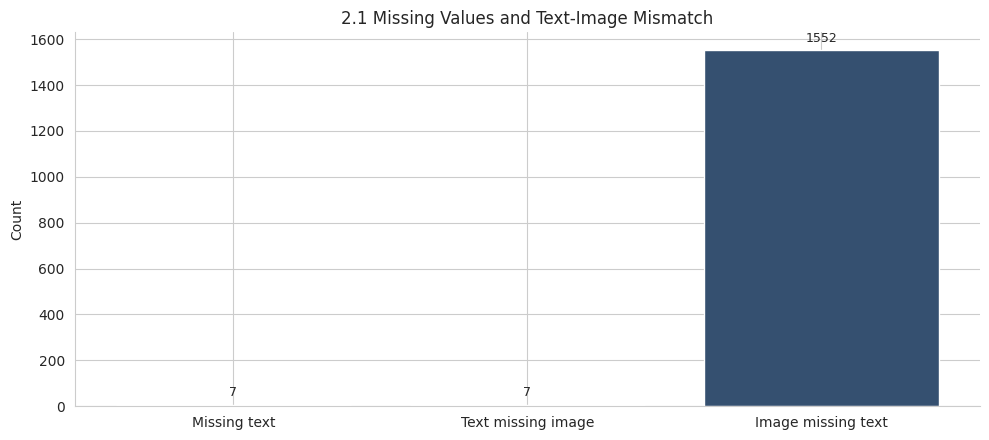


Sample text records with missing images:
['MEN-Sweaters-id_00005177-03_3_back.jpg', 'MEN-Sweatshirts_Hoodies-id_00000881-02_7_additional.jpg', 'WOMEN-Blouses_Shirts-id_00003610-04_7_additional.jpg', 'WOMEN-Blouses_Shirts-id_00006144-01_7_additional.jpg', 'WOMEN-Dresses-id_00000825-02_7_additional.jpg', 'WOMEN-Dresses-id_00002980-02_7_additional.jpg', 'WOMEN-Sweaters-id_00001262-08_3_back.jpg']

Sample image files without text records:
['MEN-Jackets_Vests-id_00000084-08_7_additional.jpg', 'MEN-Jackets_Vests-id_00000168-02_7_additional.jpg', 'MEN-Jackets_Vests-id_00000168-03_7_additional.jpg', 'MEN-Jackets_Vests-id_00000653-02_7_additional.jpg', 'MEN-Jackets_Vests-id_00000946-04_6_flat.jpg', 'MEN-Jackets_Vests-id_00002173-04_7_additional.jpg', 'MEN-Jackets_Vests-id_00002446-01_1_front.jpg', 'MEN-Jackets_Vests-id_00003311-01_1_front.jpg', 'MEN-Jackets_Vests-id_00003336-06_4_full.jpg', 'MEN-Jackets_Vests-id_00003336-06_6_flat.jpg']


In [ ]:
# ============================================================
# 2.1 - Missing values and modality mismatch
# ============================================================
caption_series = df["caption"].astype(str)
img_series = df["img_name"].astype(str).str.strip()

# Missing text inside caption records
missing_text_mask = df["caption"].isna() | (caption_series.str.strip() == "")

# Caption records that point to non-existing image files
missing_image_for_text_mask = ~img_series.isin(disk_files)

# Image files on disk that have no text record
images_without_text = sorted(disk_files - set(img_series))

summary_21 = pd.DataFrame(
    {
        "Metric": [
            "Total caption records",
            "Missing text in caption records",
            "Text records with missing image",
            "Image files without text records",
        ],
        "Count": [
            len(df),
            int(missing_text_mask.sum()),
            int(missing_image_for_text_mask.sum()),
            len(images_without_text),
        ],
    }
)

print(summary_21.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    [
        "Missing text",
        "Text missing image",
        "Image missing text",
    ],
    [
        int(missing_text_mask.sum()),
        int(missing_image_for_text_mask.sum()),
        len(images_without_text),
    ],
    color=["#b56576", "#6d597a", "#355070"],
)
ax.set_title("2.1 Missing Values and Text-Image Mismatch")
ax.set_ylabel("Count")
annotate_bars(ax)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

if missing_image_for_text_mask.any():
    print("\nSample text records with missing images:")
    print(df.loc[missing_image_for_text_mask, "img_name"].head(10).to_list())

if images_without_text:
    print("\nSample image files without text records:")
    print(images_without_text[:10])

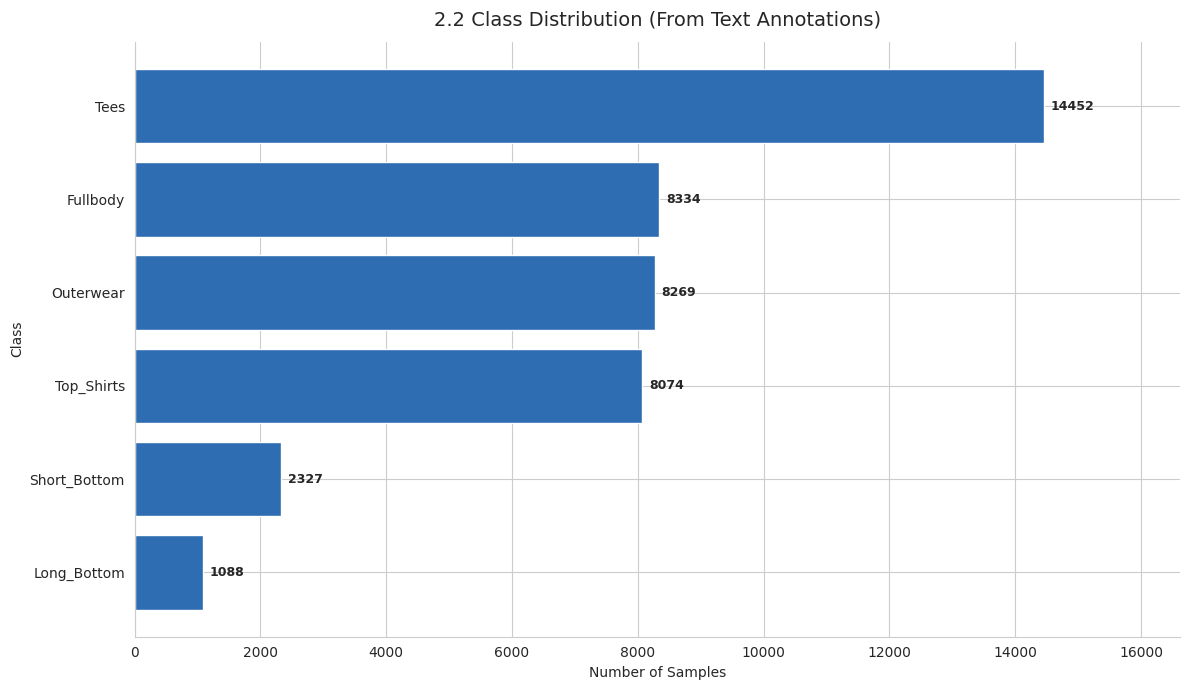

Class counts:
class
Long_Bottom      1088
Short_Bottom     2327
Top_Shirts       8074
Outerwear        8269
Fullbody         8334
Tees            14452


In [ ]:
# ============================================================
# 2.2 - Class distribution from text labels
# ============================================================
class_counts = df["class"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(class_counts.index, class_counts.values, color="#2f6db3")

# Add count labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{int(width)}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title("2.2 Class Distribution (From Text Annotations)", fontsize=14, pad=12)
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Class")
ax.set_xlim(0, class_counts.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Class counts:")
print(class_counts.to_string())

Reading image sizes:   0%|          | 0/42544 [00:00<?, ?it/s]

Image size statistics:
          width    height
count  42537.00  42537.00
mean     750.04   1100.34
std        8.84     17.69
min      750.00    915.00
25%      750.00   1101.00
50%      750.00   1101.00
75%      750.00   1101.00
max     2574.00   3861.00
Total records           : 42,544
Successfully read       : 42,537
Failed to read          : 7
Read success rate       : 99.98%


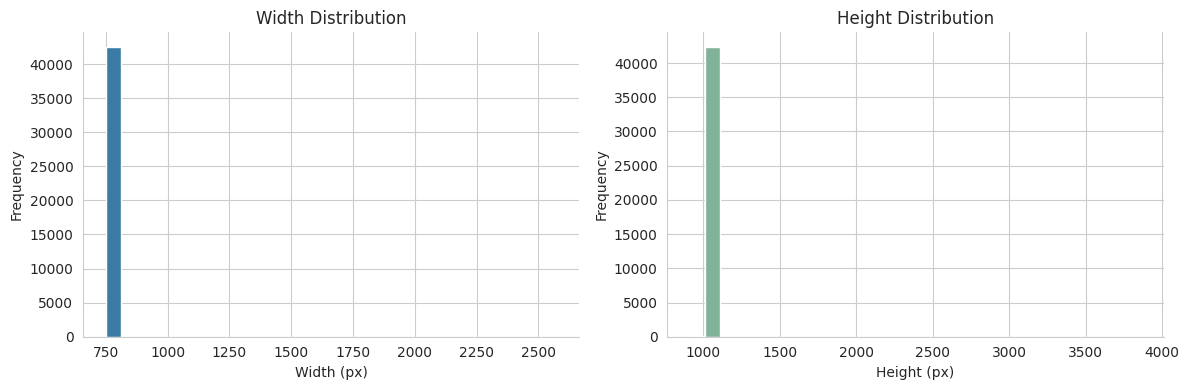

In [ ]:
# ============================================================
# 2.3 - Image size distribution
# ============================================================
image_root = Path(CONFIG["image_dir"])
widths, heights = [], []
valid_count, invalid_count = 0, 0

# Scan all referenced images to estimate width/height distributions
for name in tqdm(df["img_name"], desc="Reading image sizes"):
    p = image_root / name
    try:
        with Image.open(p) as im:
            w, h = im.size
        widths.append(w)
        heights.append(h)
        valid_count += 1
    except Exception:
        widths.append(np.nan)
        heights.append(np.nan)
        invalid_count += 1

size_df = pd.DataFrame({"width": widths, "height": heights}).dropna()

print("Image size statistics:")
print(size_df.describe().round(2))
print(f"Total records           : {len(df):,}")
print(f"Successfully read       : {valid_count:,}")
print(f"Failed to read          : {invalid_count:,}")
print(f"Read success rate       : {valid_count / len(df) * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(size_df["width"], bins=30, color="#3a7ca5", edgecolor="white")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Frequency")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].hist(size_df["height"], bins=30, color="#81b29a", edgecolor="white")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Frequency")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Caption length statistics (words):
count    42544.00
mean        40.44
std         13.79
min          0.00
25%         30.00
50%         41.00
75%         51.00
max         93.00
Name: caption_word_len, dtype: float64


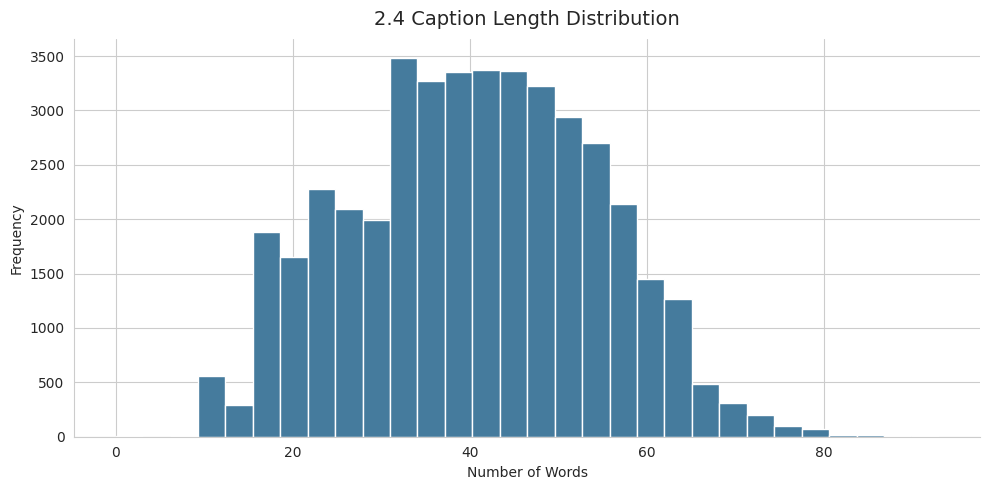


Three random full captions:
- Class: Fullbody
  Caption: This female wears a sleeveless tank shirt with graphic patterns and a three-point pants. The tank shirt is with knitting fabric. The pants are with knitting fabric and graphic patterns. The person has neckwear. There is an accessory on her wrist.

- Class: Outerwear
  Caption: The sweater this woman wears has long sleeves and it is with mixed fabric and other patterns. This person also wears an outer clothing, with leather fabric and pure color patterns. There is a ring on her finger. The female wears a hat.

- Class: Outerwear
  Caption: Her sweater has long sleeves, cotton fabric and graphic patterns. It has a v-shape neckline. This female also wears an outer clothing, with knitting fabric and pure color patterns. There is an accessory on her wrist. This lady has neckwear. There is a ring on her finger.



In [ ]:
# ============================================================
# 2.4 - Caption length analysis
# ============================================================
df["caption_word_len"] = df["caption"].astype(str).str.split().str.len()

print("Caption length statistics (words):")
print(df["caption_word_len"].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["caption_word_len"], bins=30, color="#457b9d", edgecolor="white")
ax.set_title("2.4 Caption Length Distribution", fontsize=14, pad=10)
ax.set_xlabel("Number of Words")
ax.set_ylabel("Frequency")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("\nThree random full captions:")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"- Class: {row['class']}")
    print(f"  Caption: {row['caption']}")
    print()

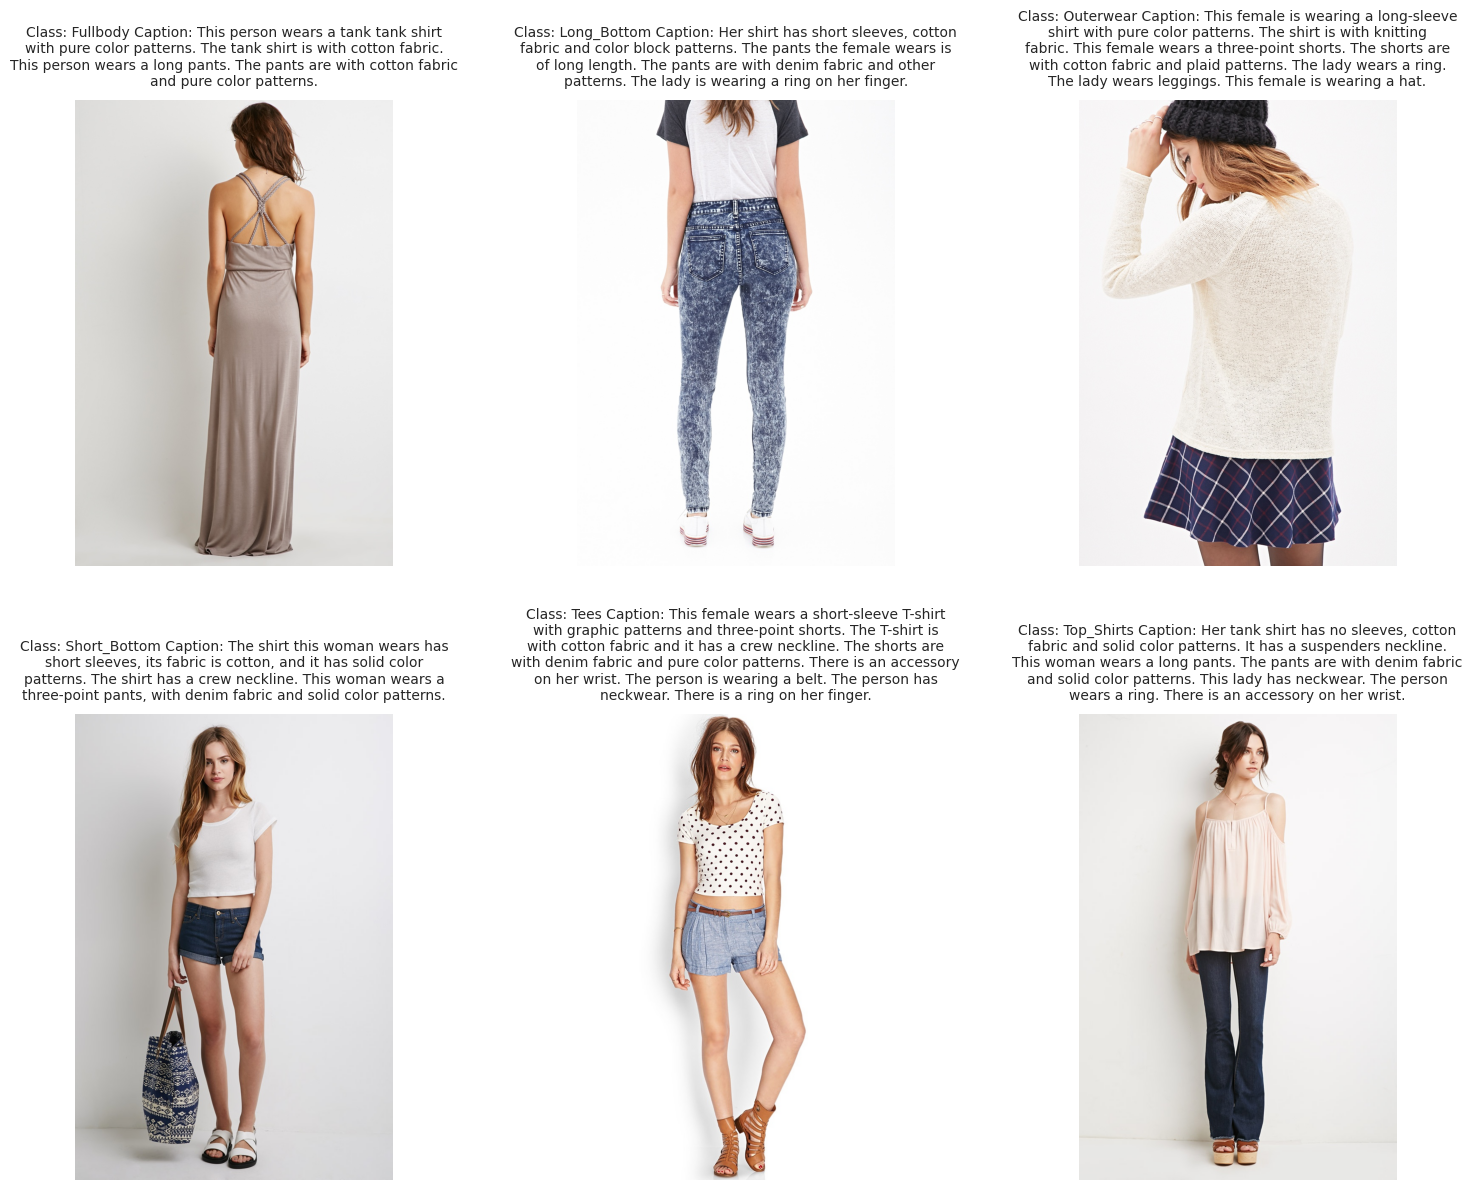

In [ ]:
# ============================================================
# 2.5 - Sample visualization (2x3 grid)
# ============================================================
import textwrap

image_root = Path(CONFIG["image_dir"])

# Pick up to 6 classes and draw one random sample for each class
unique_classes = sorted(df["class"].unique().tolist())
selected_classes = unique_classes[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, cls in enumerate(selected_classes):
    sample_row = df[df["class"] == cls].sample(1, random_state=3).iloc[0]
    img_path = image_root / sample_row["img_name"]
    caption = str(sample_row["caption"])

    ax = axes[i]
    try:
        with Image.open(img_path) as img:
            ax.imshow(img.convert("RGB"))
    except Exception:
        ax.text(0.5, 0.5, "Error loading image", ha="center", va="center", fontsize=11)

    full_title = f"Class: {cls}\nCaption: {caption}"
    wrapped_title = "\n".join(textwrap.wrap(full_title, width=64))
    ax.set_title(wrapped_title, fontsize=10, pad=10)
    ax.axis("off")

# Hide any remaining subplot axes if number of classes < 6
for j in range(len(selected_classes), len(axes)):
    axes[j].axis("off")

plt.tight_layout(h_pad=3.0, w_pad=1.0)
plt.show()

## Section 3 · Preprocessing

3.1 Remove missing captions and keep original caption values in a new column.

3.2 Label encoding.

3.3 Stratified split (Train/Val/Test) and print label distributions after split.

3.4 Caption preprocessing:
- Remove irrelevant sentences using the same logic from `remove_accessory_sentences.py`.
- Add `accessory` to the removal keyword list.
- Print caption-length statistics before vs. after preprocessing.

3.5 Image preprocessing (resize + normalize).

In [ ]:
# ============================================================
# 3.1 - Remove missing captions (keep original values)
# ============================================================

# Keep an untouched copy of caption text for auditing/comparison
if "caption_raw" not in df.columns:
    df["caption_raw"] = df["caption"]

# Normalize caption text to string and trim spaces
caption_norm = df["caption"].fillna("").astype(str).str.strip()
missing_caption_mask = caption_norm.eq("")

before_rows = len(df)
missing_rows = int(missing_caption_mask.sum())

# Drop records with missing/empty captions, then reset index
if missing_rows > 0:
    df = df.loc[~missing_caption_mask].reset_index(drop=True)
    df["caption"] = df["caption"].fillna("").astype(str).str.strip()

print("3.1 Caption missing-value cleanup")
print(f"Rows before cleanup : {before_rows:,}")
print(f"Removed empty rows  : {missing_rows:,}")
print(f"Rows after cleanup  : {len(df):,}")
print("Saved original text in column: caption_raw")

3.1 Caption missing-value cleanup
Rows before cleanup : 42,544
Removed empty rows  : 7
Rows after cleanup  : 42,537
Saved original text in column: caption_raw


3.2 Label encoding summary
Number of classes: 6
Fullbody        0
Long_Bottom     1
Outerwear       2
Short_Bottom    3
Tees            4
Top_Shirts      5

3.3 Split size summary
Total samples: 42,537
Train: 27,648 (65.0%)
Val  : 6,381 (15.0%)
Test : 8,508 (20.0%)

Label count distribution after split:
       Train   Val  Test
label                   
0       5415  1250  1667
1        707   163   218
2       5373  1240  1653
3       1513   349   465
4       9393  2168  2891
5       5247  1211  1614

Label ratio distribution after split:
       Train    Val   Test
label                     
0      19.59  19.59  19.59
1       2.56   2.55   2.56
2      19.43  19.43  19.43
3       5.47   5.47   5.47
4      33.97  33.98  33.98
5      18.98  18.98  18.97


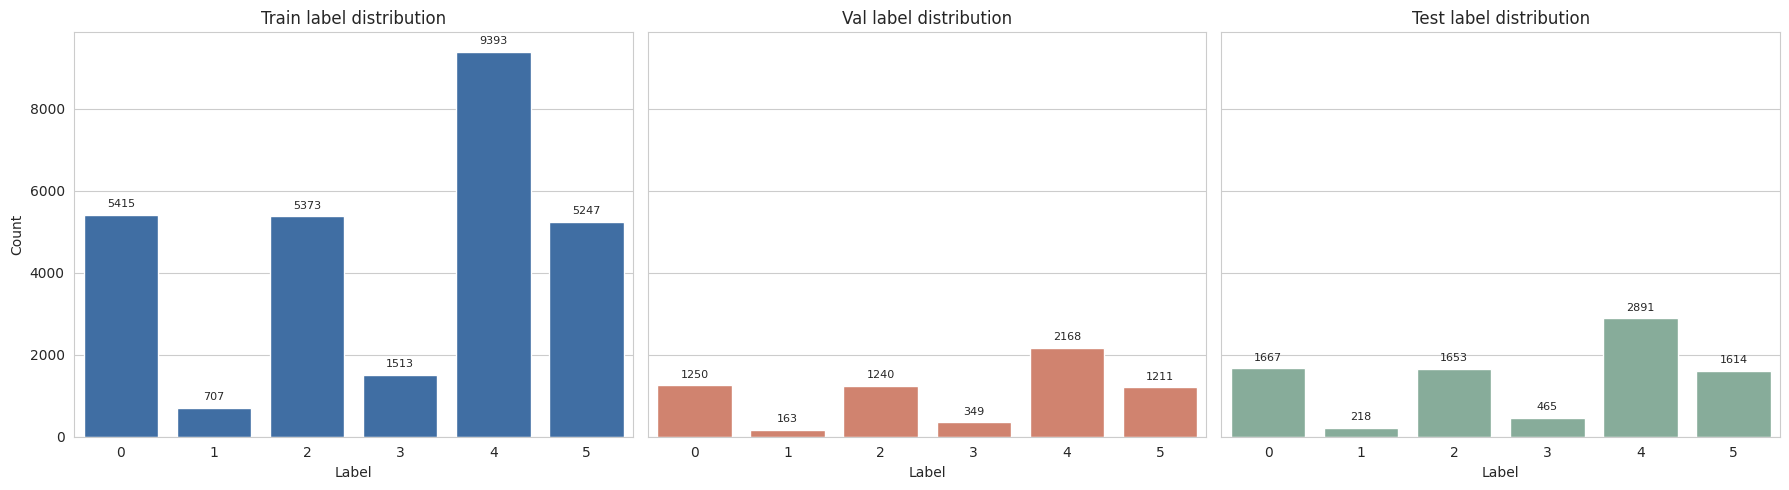


class_weights_t and train_sampler are ready for later experiments.


In [ ]:
# ============================================================
# 3.2 - Label encoding
# 3.3 - Stratified split (Train/Val/Test) + label distributions
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler

# 3.2 Label encoding
classes = sorted(df["class"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
df["label"] = df["class"].map(class2idx)

print("3.2 Label encoding summary")
print(f"Number of classes: {len(classes)}")
print(pd.Series(class2idx, name="label_id").sort_values().to_string())

# 3.3 Stratified split
test_ratio = CONFIG["test_ratio"]
val_ratio = CONFIG["val_ratio"]
val_ratio_adj = val_ratio / (1 - test_ratio)

train_val_df, test_df = train_test_split(
    df,
    test_size=test_ratio,
    stratify=df["label"],
    random_state=CONFIG["random_seed"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_ratio_adj,
    stratify=train_val_df["label"],
    random_state=CONFIG["random_seed"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n3.3 Split size summary")
print(f"Total samples: {len(df):,}")
print(f"Train: {len(train_df):,} ({len(train_df) / len(df) * 100:.1f}%)")
print(f"Val  : {len(val_df):,} ({len(val_df) / len(df) * 100:.1f}%)")
print(f"Test : {len(test_df):,} ({len(test_df) / len(df) * 100:.1f}%)")

# Print label distributions after split
label_dist = pd.DataFrame({
    "Train": train_df["label"].value_counts(normalize=True).sort_index(),
    "Val": val_df["label"].value_counts(normalize=True).sort_index(),
    "Test": test_df["label"].value_counts(normalize=True).sort_index(),
}).fillna(0.0)

label_count = pd.DataFrame({
    "Train": train_df["label"].value_counts().sort_index(),
    "Val": val_df["label"].value_counts().sort_index(),
    "Test": test_df["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

print("\nLabel count distribution after split:")
print(label_count.to_string())

print("\nLabel ratio distribution after split:")
print((label_dist * 100).round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = [
    ("Train", train_df, "#2f6db3"),
    ("Val", val_df, "#e07a5f"),
    ("Test", test_df, "#81b29a"),
]

for i, (name, split_df, color) in enumerate(splits):
    sns.countplot(data=split_df, x="label", ax=axes[i], color=color)
    axes[i].set_title(f"{name} label distribution")
    axes[i].set_xlabel("Label")
    axes[i].set_ylabel("Count" if i == 0 else "")
    for p in axes[i].patches:
        axes[i].annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

# Keep class weights and sampler for later training sections
train_labels = train_df["label"].values
classes_unique = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_unique,
    y=train_labels,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
weights_per_class = {c: w for c, w in zip(classes_unique, class_weights)}
sample_weights = [weights_per_class[label] for label in train_labels]
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

print("\nclass_weights_t and train_sampler are ready for later experiments.")

3.4 Caption preprocessing summary
Rows before caption cleaning : 42,537
Rows after caption cleaning  : 42,527
Dropped rows (empty caption) : 10
Affected captions            : 32,368
Total removed sentences      : 61,147

Caption length statistics (word count):
         Before     After
count  42527.00  42527.00
mean      40.46     30.74
std       13.78     10.27
min       10.00      6.00
25%       30.00     22.00
50%       41.00     33.00
75%       51.00     38.00
max       93.00     65.00


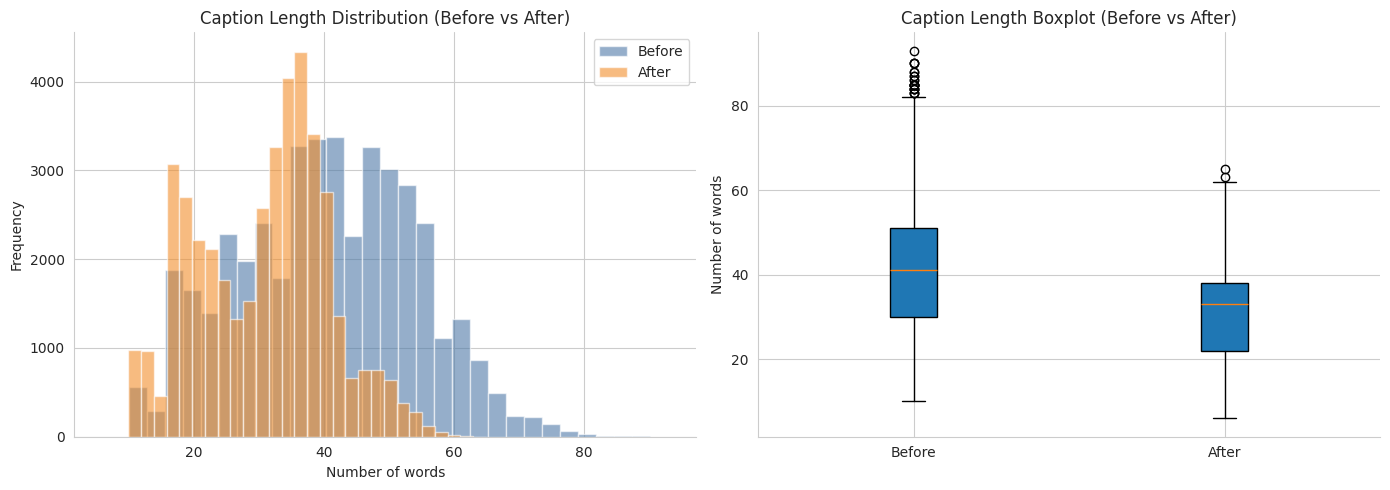


Examples (before -> after):
- Class: Long_Bottom
  Before: The upper clothing has short sleeves, cotton fabric and solid color patterns. The neckline of it is lapel. The lower clothing is of long length. The fabric is cotton and it has solid color patterns. There is an accessory...
  After : The upper clothing has short sleeves, cotton fabric and solid color patterns. The neckline of it is lapel. The lower clothing is of long length. The fabric is cotton and it has solid color patterns....

- Class: Long_Bottom
  Before: This person is wearing a short-sleeve shirt with solid color patterns. The shirt is with cotton fabric. It has a crew neckline. The pants this person wears is of short length. The pants are with cotton fabric and pure co...
  After : This person is wearing a short-sleeve shirt with solid color patterns. The shirt is with cotton fabric. It has a crew neckline. The pants this person wears is of short length. The pants are with cotton fabric and pure co...

Recomputed cl

In [ ]:
# ============================================================
# 3.4 - Caption preprocessing (remove irrelevant sentences)
# ============================================================
import re

# Keywords adapted from remove_accessory_sentences.py + added "accessory"
CAPTION_REMOVE_PATTERNS = [
    re.compile(r"\bsocks?\b", re.IGNORECASE),
    re.compile(r"\bhat\b", re.IGNORECASE),
    re.compile(r"\bglasses\b", re.IGNORECASE),
    re.compile(r"\bneckwear\b", re.IGNORECASE),
    re.compile(r"\bwrist\s+wearing\b", re.IGNORECASE),
    re.compile(r"\bring\b", re.IGNORECASE),
    re.compile(r"\bwaist\s+accessories\b", re.IGNORECASE),
    re.compile(r"\baccessor(?:y|ies)\b", re.IGNORECASE),
]


def _should_remove_sentence(sentence: str) -> bool:
    return any(pattern.search(sentence) for pattern in CAPTION_REMOVE_PATTERNS)


def _clean_caption_text(caption: str) -> tuple[str, int]:
    if not isinstance(caption, str):
        return "", 0

    raw_sentences = caption.split(".")
    kept_sentences = []
    removed = 0

    for sentence in raw_sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        if _should_remove_sentence(sentence):
            removed += 1
        else:
            kept_sentences.append(sentence)

    cleaned = ". ".join(kept_sentences).strip()
    if cleaned:
        cleaned += "."
    return cleaned, removed


# Keep immutable original caption text for stable re-runs
if "caption_before_clean" not in df.columns:
    df["caption_before_clean"] = df["caption"].astype(str)

source_caption = df["caption_before_clean"].astype(str)
clean_results = source_caption.apply(_clean_caption_text)
df["caption"] = clean_results.str[0]
df["removed_sentence_count"] = clean_results.str[1].astype(int)

affected_captions = int((df["removed_sentence_count"] > 0).sum())
total_removed_sentences = int(df["removed_sentence_count"].sum())

# Remove rows that become empty after sentence filtering
before_caption_clean_rows = len(df)
df = df.loc[df["caption"].str.strip().ne("")].reset_index(drop=True)
after_caption_clean_rows = len(df)

# Rebuild split from processed df to keep consistency
train_val_df, test_df = train_test_split(
    df,
    test_size=test_ratio,
    stratify=df["label"],
    random_state=CONFIG["random_seed"],
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_ratio_adj,
    stratify=train_val_df["label"],
    random_state=CONFIG["random_seed"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Recompute class weights/sampler after caption filtering
train_labels = train_df["label"].values
classes_unique = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_unique,
    y=train_labels,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
weights_per_class = {c: w for c, w in zip(classes_unique, class_weights)}
sample_weights = [weights_per_class[label] for label in train_labels]
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# Caption length stats before vs after processing
before_len = df["caption_before_clean"].astype(str).str.split().str.len()
after_len = df["caption"].astype(str).str.split().str.len()

stats_compare = pd.DataFrame({
    "Before": before_len.describe().round(2),
    "After": after_len.describe().round(2),
})

print("3.4 Caption preprocessing summary")
print(f"Rows before caption cleaning : {before_caption_clean_rows:,}")
print(f"Rows after caption cleaning  : {after_caption_clean_rows:,}")
print(f"Dropped rows (empty caption) : {before_caption_clean_rows - after_caption_clean_rows:,}")
print(f"Affected captions            : {affected_captions:,}")
print(f"Total removed sentences      : {total_removed_sentences:,}")

print("\nCaption length statistics (word count):")
print(stats_compare.to_string())

# Plot comparison before vs after preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(before_len, bins=30, alpha=0.6, label="Before", color="#4e79a7", edgecolor="white")
axes[0].hist(after_len, bins=30, alpha=0.6, label="After", color="#f28e2b", edgecolor="white")
axes[0].set_title("Caption Length Distribution (Before vs After)")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

box_data = [before_len.values, after_len.values]
axes[1].boxplot(box_data, labels=["Before", "After"], patch_artist=True)
axes[1].set_title("Caption Length Boxplot (Before vs After)")
axes[1].set_ylabel("Number of words")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("\nExamples (before -> after):")
sample_compare = df.loc[df["removed_sentence_count"] > 0, ["class", "caption_before_clean", "caption"]].head(2)
for _, row in sample_compare.iterrows():
    print(f"- Class: {row['class']}")
    print(f"  Before: {row['caption_before_clean'][:220]}...")
    print(f"  After : {row['caption'][:220]}...")
    print()

print("Recomputed class_weights_t and train_sampler after caption preprocessing.")

In [ ]:
# ============================================================
# 3.5 - Image preprocessing (resize + normalize)
# ============================================================
from torchvision import transforms

IMG_SIZE = (224, 224)
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

image_preprocess = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
])

print("3.5 Image preprocessing pipeline:")
print(image_preprocess)

# Quick sanity check on one sample image
sample_path = Path(CONFIG["image_dir"]) / train_df.iloc[0]["img_name"]
with Image.open(sample_path).convert("RGB") as sample_img:
    sample_tensor = image_preprocess(sample_img)

print("\nSample tensor stats after preprocess:")
print(f"Image path     : {sample_path.name}")
print(f"Tensor shape   : {tuple(sample_tensor.shape)}")
print(f"Tensor dtype   : {sample_tensor.dtype}")
print(f"Min / Max      : {sample_tensor.min().item():.4f} / {sample_tensor.max().item():.4f}")
print(f"Mean / Std     : {sample_tensor.mean().item():.4f} / {sample_tensor.std().item():.4f}")

3.5 Image preprocessing pipeline:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
)

Sample tensor stats after preprocess:
Image path     : WOMEN-Sweatshirts_Hoodies-id_00007198-04_1_front.jpg
Tensor shape   : (3, 224, 224)
Tensor dtype   : torch.float32
Min / Max      : -1.5441 / 2.0890
Mean / Std     : 1.4020 / 0.9561


## Sec 4 · On-demand Feature Encoding (Simple)

Muc tieu: chi giu 1 API can dung la `get_features(model_key, split_name)`.

- Khong pre-encode truoc.
- Tu dong encode khi can va luu vao RAM (`FEATURE_CACHE`).
- Du de chay Section 5 va Section 6.

In [ ]:
# ============================================================
# 4.3 - Simple lazy feature loader (single source of truth)
# ============================================================
import os
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import clip

os.makedirs(CONFIG["cache_dir"], exist_ok=True)

SPLITS = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}

MODEL_KEY_TO_NAME = {m.replace("/", "-"): m for m in CONFIG["clip_models"]}
FEATURE_CACHE = {model_key: {} for model_key in MODEL_KEY_TO_NAME}
_CLIP_RUNTIME = {}


class FashionDataset(Dataset):
    def __init__(self, dataframe, image_dir, preprocess):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / row["img_name"]
        image = self.preprocess(Image.open(img_path).convert("RGB"))
        caption = str(row["caption"])
        label = int(row["label"])
        return image, caption, label


@torch.no_grad()
def extract_features(model, dataframe, image_dir, preprocess, batch_size=256, device=DEVICE):
    dataset = FashionDataset(dataframe, image_dir, preprocess)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(device == "cuda"),
    )

    model.eval()
    all_img, all_txt, all_lbl = [], [], []

    for images, captions, labels in loader:
        images = images.to(device)
        img_feat = F.normalize(model.encode_image(images).float(), dim=-1)
        tokens = clip.tokenize(list(captions), truncate=True).to(device)
        txt_feat = F.normalize(model.encode_text(tokens).float(), dim=-1)

        all_img.append(img_feat.cpu())
        all_txt.append(txt_feat.cpu())
        all_lbl.append(labels)

    return {
        "img_features": torch.cat(all_img, dim=0),
        "text_features": torch.cat(all_txt, dim=0),
        "labels": torch.cat(all_lbl, dim=0),
    }


def get_clip_runtime(model_key, device=DEVICE):
    if model_key not in MODEL_KEY_TO_NAME:
        raise KeyError(f"Unknown model key: {model_key}. Available: {list(MODEL_KEY_TO_NAME.keys())}")

    if model_key not in _CLIP_RUNTIME:
        model_name = MODEL_KEY_TO_NAME[model_key]
        model, preprocess = clip.load(model_name, device=device)
        model.eval()
        _CLIP_RUNTIME[model_key] = {"model": model, "preprocess": preprocess}
        print(f"[model] Loaded {model_name}")

    return _CLIP_RUNTIME[model_key]


def get_features(model_key, split_name, force_recompute=False):
    if split_name not in SPLITS:
        raise KeyError(f"Unknown split: {split_name}. Available: {list(SPLITS.keys())}")
    if model_key not in FEATURE_CACHE:
        raise KeyError(f"Unknown model key: {model_key}. Available: {list(FEATURE_CACHE.keys())}")

    if not force_recompute and split_name in FEATURE_CACHE[model_key]:
        return FEATURE_CACHE[model_key][split_name]

    runtime = get_clip_runtime(model_key, device=DEVICE)
    feats = extract_features(
        model=runtime["model"],
        dataframe=SPLITS[split_name],
        image_dir=CONFIG["image_dir"],
        preprocess=runtime["preprocess"],
        batch_size=CONFIG["batch_size"],
        device=DEVICE,
    )
    FEATURE_CACHE[model_key][split_name] = feats
    return feats


print("Sec 4 simple loader ready: get_features(model_key, split_name)")

Sec 4 simple loader ready: get_features(model_key, split_name)


In [ ]:
# 4.4 - Optional quick status (khong auto-encode de tiet kiem thoi gian)
print(f"{'Model':<12} {'Split':<8} {'Status'}")
print("-" * 40)
for model_key in FEATURE_CACHE:
    for split_name in SPLITS:
        status = "loaded" if split_name in FEATURE_CACHE[model_key] else "pending"
        print(f"{model_key:<12} {split_name:<8} {status}")

print("\nTip: goi get_features('ViT-B-32', 'train') khi can.")

Model        Split    Status
----------------------------------------
ViT-B-32     train    pending
ViT-B-32     val      pending
ViT-B-32     test     pending
ViT-L-14     train    pending
ViT-L-14     val      pending
ViT-L-14     test     pending

Tip: goi get_features('ViT-B-32', 'train') khi can.


## Section 5 · Model Design & Experiments

This section runs 8 experiments on the validation set:

- E1: Zero-shot image classification (ViT-B/32)
- E2: Zero-shot image classification (ViT-L/14)
- E3: Prompt engineering with 4 templates + ensemble (ViT-B/32)
- E4: Multimodal zero-shot using `class prompt + real caption`
- F1: Few-shot image linear probe (ViT-B/32), k = {1, 4, 8, 16}
- F2: Few-shot image linear probe (ViT-L/14), k = {1, 4, 8, 16}
- F3: Few-shot text probe, synthetic prompt text vs real caption text
- F4: Few-shot multimodal fusion with enriched caption, k = {4, 16}

Rule:
- Keep test-set evaluation for Section 6.
- Use validation set for experiment comparison and model-selection decisions.

In [ ]:
# ============================================================
# 5.0 - Shared utilities for E1..E4 and F1..F4
# ============================================================
import os
import time
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import clip

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

RESULTS = {}


def compute_metrics(y_true, y_pred):
    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def print_metrics(name, metrics, extra=""):
    print(
        f"  {name:<28} Acc={metrics['acc']:.4f}  "
        f"F1-macro={metrics['f1_macro']:.4f}  F1-weighted={metrics['f1_weighted']:.4f} {extra}"
    )


@torch.no_grad()
def zero_shot_classify(img_features, class_names, prompt_template, model, device=DEVICE):
    prompts = [prompt_template.format(cls=c.replace("_", " ").lower()) for c in class_names]
    tokens = clip.tokenize(prompts, truncate=True).to(device)
    txt_embs = model.encode_text(tokens).float()
    txt_embs = F.normalize(txt_embs, dim=-1)
    sims = img_features.to(device) @ txt_embs.T
    return sims.argmax(dim=1).cpu().numpy()


@torch.no_grad()
def encode_texts_batched(text_list, model, batch_size=512, device=DEVICE):
    all_emb = []
    for i in range(0, len(text_list), batch_size):
        chunk = text_list[i : i + batch_size]
        tokens = clip.tokenize(chunk, truncate=True).to(device)
        emb = model.encode_text(tokens).float()
        emb = F.normalize(emb, dim=-1)
        all_emb.append(emb.cpu())
    return torch.cat(all_emb, dim=0)


def sample_k_shot_indices(labels_np, k, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for c in np.unique(labels_np):
        c_idx = np.where(labels_np == c)[0]
        take = min(k, len(c_idx))
        idx.extend(rng.choice(c_idx, size=take, replace=False).tolist())
    rng.shuffle(idx)
    return np.array(idx, dtype=np.int64)


def run_few_shot_probe(X_train_full, y_train, X_val, y_val, ks, n_runs=5, seed_base=42):
    out = {}
    for k in ks:
        accs, f1s = [], []
        for run in range(n_runs):
            idx = sample_k_shot_indices(y_train, k, seed=seed_base + run)
            X_tr = X_train_full[idx]
            y_tr = y_train[idx]

            clf = LogisticRegression(
                max_iter=1000,
                C=0.316,
                random_state=seed_base + run,
                solver="lbfgs",
                multi_class="multinomial",
            )
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_val)
            accs.append(accuracy_score(y_val, preds))
            f1s.append(f1_score(y_val, preds, average="macro", zero_division=0))

        out[k] = {
            "acc_mean": float(np.mean(accs)),
            "acc_std": float(np.std(accs)),
            "f1_mean": float(np.mean(f1s)),
            "f1_std": float(np.std(f1s)),
        }
    return out


# Fallback: define get_features if Section 4 was not executed.
if "get_features" not in globals():
    class FashionDataset(Dataset):
        def __init__(self, dataframe, image_dir, preprocess):
            self.df = dataframe.reset_index(drop=True)
            self.image_dir = Path(image_dir)
            self.preprocess = preprocess

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = self.image_dir / row["img_name"]
            image = self.preprocess(Image.open(img_path).convert("RGB"))
            caption = str(row["caption"])
            label = int(row["label"])
            return image, caption, label

    @torch.no_grad()
    def extract_features(model, dataframe, image_dir, preprocess, batch_size=256, device=DEVICE):
        dataset = FashionDataset(dataframe, image_dir, preprocess)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=(device == "cuda"),
        )

        model.eval()
        all_img, all_txt, all_lbl = [], [], []
        for images, captions, labels in loader:
            images = images.to(device)
            img_feat = model.encode_image(images).float()
            img_feat = F.normalize(img_feat, dim=-1)

            tokens = clip.tokenize(list(captions), truncate=True).to(device)
            txt_feat = model.encode_text(tokens).float()
            txt_feat = F.normalize(txt_feat, dim=-1)

            all_img.append(img_feat.cpu())
            all_txt.append(txt_feat.cpu())
            all_lbl.append(labels)

        return {
            "img_features": torch.cat(all_img, dim=0),
            "text_features": torch.cat(all_txt, dim=0),
            "labels": torch.cat(all_lbl, dim=0),
        }

    SPLITS = {"train": train_df, "val": val_df, "test": test_df}
    MODEL_KEY_TO_NAME = {m.replace("/", "-"): m for m in CONFIG["clip_models"]}
    FEATURE_CACHE = {model_key: {} for model_key in MODEL_KEY_TO_NAME}
    _CLIP_RUNTIME = {}

    def get_clip_runtime(model_key, device=DEVICE):
        if model_key not in MODEL_KEY_TO_NAME:
            raise KeyError(f"Unknown model key: {model_key}")
        if model_key not in _CLIP_RUNTIME:
            model_name = MODEL_KEY_TO_NAME[model_key]
            model, preprocess = clip.load(model_name, device=device)
            model.eval()
            _CLIP_RUNTIME[model_key] = {"model": model, "preprocess": preprocess}
            print(f"[model] Loaded {model_name} on-demand.")
        return _CLIP_RUNTIME[model_key]

    def get_features(model_key, split_name, force_recompute=False):
        if split_name not in SPLITS:
            raise KeyError(f"Unknown split: {split_name}")
        if model_key not in FEATURE_CACHE:
            raise KeyError(f"Unknown model key: {model_key}")

        if not force_recompute and split_name in FEATURE_CACHE[model_key]:
            return FEATURE_CACHE[model_key][split_name]

        runtime = get_clip_runtime(model_key, device=DEVICE)
        feats = extract_features(
            model=runtime["model"],
            dataframe=SPLITS[split_name],
            image_dir=CONFIG["image_dir"],
            preprocess=runtime["preprocess"],
            batch_size=CONFIG["batch_size"],
            device=DEVICE,
        )
        FEATURE_CACHE[model_key][split_name] = feats
        return feats

    print("Section 4 fallback loaded inside Section 5 (get_features is now available).")

NUM_CLASSES = len(classes)
KS = [1, 4, 8, 16]
N_RUNS = int(CONFIG.get("n_runs", 5))
SEED_BASE = int(CONFIG.get("random_seed", 42))

print("Section 5 utilities loaded.")
print(f"NUM_CLASSES = {NUM_CLASSES}")

Section 5 utilities loaded.
NUM_CLASSES = 6


In [ ]:
# ============================================================
# E1 - Zero-shot image classification (ViT-B/32)
# Prompt: "a photo of {class} clothing"
# ============================================================
val_feats_b32 = get_features("ViT-B-32", "val")
val_img_feats_b32 = val_feats_b32["img_features"]
val_labels_b32 = val_feats_b32["labels"].numpy()

PROMPT_SIMPLE = "a photo of {cls} clothing"

model_e1, _ = clip.load("ViT-B/32", device=DEVICE)
model_e1.eval()

t0 = time.perf_counter()
preds_e1 = zero_shot_classify(val_img_feats_b32, classes, PROMPT_SIMPLE, model_e1)
t_e1 = time.perf_counter() - t0

m_e1 = compute_metrics(val_labels_b32, preds_e1)
m_e1["inference_ms"] = t_e1 / len(val_labels_b32) * 1000
RESULTS["E1_ZeroShot_ViTB32"] = m_e1

print("E1 - Zero-shot ViT-B/32 (validation set)")
print_metrics("E1", m_e1, f"({t_e1*1000:.0f}ms total)")

del model_e1
if DEVICE == "cuda":
    torch.cuda.empty_cache()

100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 52.8MiB/s]


[model] Loaded ViT-B/32
E1 - Zero-shot ViT-B/32 (validation set)
  E1                           Acc=0.3918  F1-macro=0.3172  F1-weighted=0.3227 (37ms total)


In [ ]:
# ============================================================
# E2 - Zero-shot image classification (ViT-L/14)
# Compare directly against E1 to measure backbone-size impact
# ============================================================
val_feats_l14 = get_features("ViT-L-14", "val")
val_img_feats_l14 = val_feats_l14["img_features"]
val_labels_l14 = val_feats_l14["labels"].numpy()

model_e2, _ = clip.load("ViT-L/14", device=DEVICE)
model_e2.eval()

t0 = time.perf_counter()
preds_e2 = zero_shot_classify(val_img_feats_l14, classes, PROMPT_SIMPLE, model_e2)
t_e2 = time.perf_counter() - t0

m_e2 = compute_metrics(val_labels_l14, preds_e2)
m_e2["inference_ms"] = t_e2 / len(val_labels_l14) * 1000
RESULTS["E2_ZeroShot_ViTL14"] = m_e2

print("E2 - Zero-shot ViT-L/14 (validation set)")
print_metrics("E2", m_e2, f"({t_e2*1000:.0f}ms total)")
print(f"Backbone delta vs E1 (Accuracy): {(m_e2['acc'] - m_e1['acc']) * 100:+.2f}%")

del model_e2
if DEVICE == "cuda":
    torch.cuda.empty_cache()

100%|███████████████████████████████████████| 890M/890M [00:12<00:00, 74.2MiB/s]


[model] Loaded ViT-L/14
E2 - Zero-shot ViT-L/14 (validation set)
  E2                           Acc=0.5074  F1-macro=0.4404  F1-weighted=0.5281 (21ms total)
Backbone delta vs E1 (Accuracy): +11.57%


In [ ]:
# ============================================================
# E3 - Prompt engineering (ViT-B/32)
# 4 templates + ensemble (average class embeddings)
# ============================================================
PROMPT_TEMPLATES = {
    "simple": "a photo of {cls}",
    "fashion": "a fashion photo of {cls} clothing",
    "detailed": "a photo of a person wearing {cls}",
    "context": "this is a {cls} garment",
}


@torch.no_grad()
def zero_shot_ensemble(img_features, class_names, templates_dict, model, device=DEVICE):
    all_class_embs = []
    for tmpl in templates_dict.values():
        prompts = [tmpl.format(cls=c.replace("_", " ").lower()) for c in class_names]
        tokens = clip.tokenize(prompts, truncate=True).to(device)
        embs = model.encode_text(tokens).float()
        embs = F.normalize(embs, dim=-1)
        all_class_embs.append(embs)

    ensemble_emb = torch.stack(all_class_embs, dim=0).mean(dim=0)
    ensemble_emb = F.normalize(ensemble_emb, dim=-1)
    sims = img_features.to(device) @ ensemble_emb.T
    return sims.argmax(dim=1).cpu().numpy()


model_e3, _ = clip.load("ViT-B/32", device=DEVICE)
model_e3.eval()

print("E3 - Prompt engineering (validation set)")
E3_template_results = {}
best_template, best_acc = None, -1.0

for name, tmpl in PROMPT_TEMPLATES.items():
    preds = zero_shot_classify(val_img_feats_b32, classes, tmpl, model_e3)
    m = compute_metrics(val_labels_b32, preds)
    E3_template_results[name] = m
    if m["acc"] > best_acc:
        best_acc = m["acc"]
        best_template = name
    print_metrics(f"E3 template={name}", m)

preds_e3_ens = zero_shot_ensemble(val_img_feats_b32, classes, PROMPT_TEMPLATES, model_e3)
m_e3_ens = compute_metrics(val_labels_b32, preds_e3_ens)
print_metrics("E3 ensemble", m_e3_ens)

RESULTS["E3_PromptEngineering"] = {
    "templates": E3_template_results,
    "ensemble": m_e3_ens,
    "best_template": best_template,
}

# Keep backward-compatible keys for later sections
RESULTS["E3_PromptEng_best"] = dict(E3_template_results[best_template])
RESULTS["E3_PromptEng_best"]["best_template"] = best_template
RESULTS["E3_PromptEng_ensemble"] = m_e3_ens

print(f"Best single template: {best_template}")

del model_e3
if DEVICE == "cuda":
    torch.cuda.empty_cache()

E3 - Prompt engineering (validation set)
  E3 template=simple           Acc=0.4250  F1-macro=0.2717  F1-weighted=0.3163 
  E3 template=fashion          Acc=0.4110  F1-macro=0.3627  F1-weighted=0.3677 
  E3 template=detailed         Acc=0.4806  F1-macro=0.4170  F1-weighted=0.5123 
  E3 template=context          Acc=0.3645  F1-macro=0.3326  F1-weighted=0.3899 
  E3 ensemble                  Acc=0.4676  F1-macro=0.4084  F1-weighted=0.4396 
Best single template: detailed


In [ ]:
# ============================================================
# E4 - Multimodal zero-shot (ViT-B/32)
# Replace class-only prompt with: "class prompt + real caption"
# ============================================================

@torch.no_grad()
def multimodal_zero_shot_with_caption(img_features, captions, class_names, model, device=DEVICE):
    class_text = [c.replace("_", " ").lower() for c in class_names]
    n = len(captions)
    c = len(class_names)

    # Build (N * C) prompts and encode in batches
    all_prompts = []
    for cap in captions:
        cap = str(cap)
        all_prompts.extend([f"a photo of {cls} clothing. {cap}" for cls in class_text])

    txt_emb = encode_texts_batched(all_prompts, model=model, batch_size=512, device=device)
    txt_emb = txt_emb.view(n, c, -1).to(device)  # [N, C, D]
    img = img_features.to(device).unsqueeze(1)   # [N, 1, D]

    sims = (img * txt_emb).sum(dim=-1)           # [N, C]
    preds = sims.argmax(dim=1).cpu().numpy()
    return preds


val_captions = val_df["caption"].astype(str).tolist()

model_e4, _ = clip.load("ViT-B/32", device=DEVICE)
model_e4.eval()

t0 = time.perf_counter()
preds_e4 = multimodal_zero_shot_with_caption(
    img_features=val_img_feats_b32,
    captions=val_captions,
    class_names=classes,
    model=model_e4,
    device=DEVICE,
)
t_e4 = time.perf_counter() - t0

m_e4 = compute_metrics(val_labels_b32, preds_e4)
m_e4["inference_ms"] = t_e4 / len(val_labels_b32) * 1000
RESULTS["E4_Multimodal_ZeroShot"] = m_e4

print("E4 - Multimodal zero-shot (class prompt + real caption)")
print_metrics("E4", m_e4, f"({t_e4*1000:.0f}ms total)")
print(f"Delta vs E1 (Accuracy): {(m_e4['acc'] - m_e1['acc']) * 100:+.2f}%")

del model_e4
if DEVICE == "cuda":
    torch.cuda.empty_cache()

E4 - Multimodal zero-shot (class prompt + real caption)
  E4                           Acc=0.3024  F1-macro=0.2609  F1-weighted=0.3336 (35072ms total)
Delta vs E1 (Accuracy): -8.94%


In [ ]:
# ============================================================
# F1 - Few-shot Image Linear Probe (ViT-B/32), k={1,4,8,16}
# ============================================================
tr_feats_b32 = get_features("ViT-B-32", "train")
vl_feats_b32 = get_features("ViT-B-32", "val")

y_train_b32 = tr_feats_b32["labels"].numpy()
y_val_b32 = vl_feats_b32["labels"].numpy()
X_train_img_b32 = tr_feats_b32["img_features"].numpy()
X_val_img_b32 = vl_feats_b32["img_features"].numpy()

F1_results = run_few_shot_probe(
    X_train_full=X_train_img_b32,
    y_train=y_train_b32,
    X_val=X_val_img_b32,
    y_val=y_val_b32,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

print("F1 - Few-shot Image Linear Probe (ViT-B/32)")
for k in KS:
    r = F1_results[k]
    print(f"  k={k:>2}: Acc={r['acc_mean']:.4f}±{r['acc_std']:.4f}  F1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")

RESULTS["F1_FewShot_Image_ViTB32"] = F1_results

# Backward-compatible alias
E5_results = F1_results
RESULTS["E5_FewShot_Image"] = E5_results

F1 - Few-shot Image Linear Probe (ViT-B/32)
  k= 1: Acc=0.3117±0.0590  F1=0.2758±0.0508
  k= 4: Acc=0.4323±0.0265  F1=0.3850±0.0179
  k= 8: Acc=0.4797±0.0292  F1=0.4309±0.0198
  k=16: Acc=0.5394±0.0183  F1=0.4933±0.0193


In [ ]:
# ============================================================
# F2 - Few-shot Image Linear Probe (ViT-L/14), k={1,4,8,16}
# ============================================================
tr_feats_l14 = get_features("ViT-L-14", "train")
vl_feats_l14 = get_features("ViT-L-14", "val")

y_train_l14 = tr_feats_l14["labels"].numpy()
y_val_l14 = vl_feats_l14["labels"].numpy()
X_train_img_l14 = tr_feats_l14["img_features"].numpy()
X_val_img_l14 = vl_feats_l14["img_features"].numpy()

F2_results = run_few_shot_probe(
    X_train_full=X_train_img_l14,
    y_train=y_train_l14,
    X_val=X_val_img_l14,
    y_val=y_val_l14,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

print("F2 - Few-shot Image Linear Probe (ViT-L/14)")
for k in KS:
    r = F2_results[k]
    print(f"  k={k:>2}: Acc={r['acc_mean']:.4f}±{r['acc_std']:.4f}  F1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")

print("\nBackbone comparison at k=16 (F2 - F1):")
print(f"  Acc delta: {F2_results[16]['acc_mean'] - F1_results[16]['acc_mean']:+.4f}")
print(f"  F1  delta: {F2_results[16]['f1_mean'] - F1_results[16]['f1_mean']:+.4f}")

RESULTS["F2_FewShot_Image_ViTL14"] = F2_results

F2 - Few-shot Image Linear Probe (ViT-L/14)
  k= 1: Acc=0.3357±0.0571  F1=0.2891±0.0438
  k= 4: Acc=0.5036±0.0496  F1=0.4489±0.0311
  k= 8: Acc=0.5477±0.0255  F1=0.4944±0.0169
  k=16: Acc=0.6105±0.0267  F1=0.5598±0.0246

Backbone comparison at k=16 (F2 - F1):
  Acc delta: +0.0711
  F1  delta: +0.0665


In [ ]:
# ============================================================
# F3 - Few-shot Text Probe: Synthetic vs Real captions
# k={1,4,8,16}
# ============================================================
model_f3, _ = clip.load("ViT-B/32", device=DEVICE)
model_f3.eval()

# Real caption features from Section 4 cache
X_train_text_real = tr_feats_b32["text_features"].numpy()
X_val_text_real = vl_feats_b32["text_features"].numpy()

# Synthetic text features: prompt built from class label
syn_template = "a fashion photo of {cls} clothing"
class_prompts = [syn_template.format(cls=c.replace("_", " ").lower()) for c in classes]
class_prompt_emb = encode_texts_batched(class_prompts, model_f3, batch_size=64, device=DEVICE).numpy()

# Map each sample label -> class prompt embedding
X_train_text_syn = class_prompt_emb[y_train_b32]

# F3a: train on synthetic text, evaluate on real caption text
F3_synthetic_results = run_few_shot_probe(
    X_train_full=X_train_text_syn,
    y_train=y_train_b32,
    X_val=X_val_text_real,
    y_val=y_val_b32,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

# F3b: train on real caption text, evaluate on real caption text
F3_real_results = run_few_shot_probe(
    X_train_full=X_train_text_real,
    y_train=y_train_b32,
    X_val=X_val_text_real,
    y_val=y_val_b32,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

print("F3 - Few-shot Text Probe")
for k in KS:
    rs = F3_synthetic_results[k]
    rr = F3_real_results[k]
    print(
        f"  k={k:>2}: synthetic Acc={rs['acc_mean']:.4f}±{rs['acc_std']:.4f}, "
        f"F1={rs['f1_mean']:.4f}±{rs['f1_std']:.4f} | "
        f"real Acc={rr['acc_mean']:.4f}±{rr['acc_std']:.4f}, "
        f"F1={rr['f1_mean']:.4f}±{rr['f1_std']:.4f} | "
        f"delta_acc(real-syn)={rr['acc_mean'] - rs['acc_mean']:+.4f}, "
        f"delta_f1(real-syn)={rr['f1_mean'] - rs['f1_mean']:+.4f}"
    )

RESULTS["F3_TextProbe_SyntheticVsReal"] = {
    "synthetic": F3_synthetic_results,
    "real": F3_real_results,
}

# Backward-compatible alias
E6_results = F3_real_results
RESULTS["E6_FewShot_Text"] = E6_results

del model_f3
if DEVICE == "cuda":
    torch.cuda.empty_cache()

F3 - Few-shot Text Probe
  k= 1: synthetic Acc=0.2863±0.0000, F1=0.2143±0.0000 | real Acc=0.2609±0.0617, F1=0.2181±0.0516 | delta_acc(real-syn)=-0.0253, delta_f1(real-syn)=+0.0038
  k= 4: synthetic Acc=0.2844±0.0000, F1=0.2132±0.0000 | real Acc=0.3181±0.0365, F1=0.2671±0.0291 | delta_acc(real-syn)=+0.0337, delta_f1(real-syn)=+0.0539
  k= 8: synthetic Acc=0.2850±0.0000, F1=0.2156±0.0000 | real Acc=0.3528±0.0445, F1=0.2934±0.0397 | delta_acc(real-syn)=+0.0678, delta_f1(real-syn)=+0.0778
  k=16: synthetic Acc=0.2809±0.0000, F1=0.2131±0.0000 | real Acc=0.3927±0.0121, F1=0.3355±0.0140 | delta_acc(real-syn)=+0.1118, delta_f1(real-syn)=+0.1224


In [ ]:
# ============================================================
# F4 - Few-shot Multimodal Fusion: Image + Enriched Caption
# k={4,16}
# enriched caption = real caption + "This is {class} clothing."
# ============================================================
model_f4, _ = clip.load("ViT-B/32", device=DEVICE)
model_f4.eval()

train_enriched_text = [
    f"{cap} This is {cls.replace('_', ' ').lower()} clothing."
    for cap, cls in zip(train_df["caption"].astype(str).tolist(), train_df["class"].astype(str).tolist())
]
val_enriched_text = [
    f"{cap} This is {cls.replace('_', ' ').lower()} clothing."
    for cap, cls in zip(val_df["caption"].astype(str).tolist(), val_df["class"].astype(str).tolist())
]

train_enriched_emb = encode_texts_batched(train_enriched_text, model_f4, batch_size=256, device=DEVICE)
val_enriched_emb = encode_texts_batched(val_enriched_text, model_f4, batch_size=256, device=DEVICE)

X_train_fused_enriched = torch.cat([tr_feats_b32["img_features"], train_enriched_emb], dim=1).numpy()
X_val_fused_enriched = torch.cat([vl_feats_b32["img_features"], val_enriched_emb], dim=1).numpy()

F4_results = run_few_shot_probe(
    X_train_full=X_train_fused_enriched,
    y_train=y_train_b32,
    X_val=X_val_fused_enriched,
    y_val=y_val_b32,
    ks=[4, 16],
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

print("F4 - Few-shot Multimodal Fusion (Image + Enriched Caption)")
for k in [4, 16]:
    r = F4_results[k]
    img_acc = F1_results[k]["acc_mean"]
    img_f1 = F1_results[k]["f1_mean"]
    print(
        f"  k={k:>2}: Fusion Acc={r['acc_mean']:.4f}±{r['acc_std']:.4f}, "
        f"F1={r['f1_mean']:.4f}±{r['f1_std']:.4f} | "
        f"Image-only Acc={img_acc:.4f}, F1={img_f1:.4f} | "
        f"gain Acc={r['acc_mean'] - img_acc:+.4f}, gain F1={r['f1_mean'] - img_f1:+.4f}"
    )

RESULTS["F4_FewShot_Fusion_Enriched"] = F4_results

# Backward-compatible alias
E7_results = F4_results
RESULTS["E7_FewShot_Fusion"] = E7_results

del model_f4
if DEVICE == "cuda":
    torch.cuda.empty_cache()

F4 - Few-shot Multimodal Fusion (Image + Enriched Caption)
  k= 4: Fusion Acc=0.5320±0.0250, F1=0.4564±0.0188 | Image-only Acc=0.4323, F1=0.3850 | gain Acc=+0.0997, gain F1=+0.0714
  k=16: Fusion Acc=0.6629±0.0241, F1=0.5936±0.0272 | Image-only Acc=0.5394, F1=0.4933 | gain Acc=+0.1235, gain F1=+0.1004


In [ ]:
# ============================================================
# 5.x - Validation summary table (prioritize F1-macro)
# ============================================================
def _best_curve_point(curve_dict):
    best_k = max(curve_dict, key=lambda k: curve_dict[k]["f1_mean"])
    return int(best_k), curve_dict[best_k]

best_k_f1, best_f1 = _best_curve_point(F1_results)
best_k_f2, best_f2 = _best_curve_point(F2_results)
best_k_f3, best_f3 = _best_curve_point(F3_real_results)
best_k_f4, best_f4 = _best_curve_point(F4_results)

summary_rows_sec5 = [
    {
        "Experiment": "E1 Zero-shot ViT-B/32",
        "Accuracy": RESULTS["E1_ZeroShot_ViTB32"]["acc"],
        "F1-macro": RESULTS["E1_ZeroShot_ViTB32"]["f1_macro"],
        "F1-weighted": RESULTS["E1_ZeroShot_ViTB32"]["f1_weighted"],
        "Inference(ms/sample)": RESULTS["E1_ZeroShot_ViTB32"].get("inference_ms", np.nan),
    },
    {
        "Experiment": "E2 Zero-shot ViT-L/14",
        "Accuracy": RESULTS["E2_ZeroShot_ViTL14"]["acc"],
        "F1-macro": RESULTS["E2_ZeroShot_ViTL14"]["f1_macro"],
        "F1-weighted": RESULTS["E2_ZeroShot_ViTL14"]["f1_weighted"],
        "Inference(ms/sample)": RESULTS["E2_ZeroShot_ViTL14"].get("inference_ms", np.nan),
    },
    {
        "Experiment": "E3 Prompt Engineering (ensemble)",
        "Accuracy": RESULTS["E3_PromptEng_ensemble"]["acc"],
        "F1-macro": RESULTS["E3_PromptEng_ensemble"]["f1_macro"],
        "F1-weighted": RESULTS["E3_PromptEng_ensemble"]["f1_weighted"],
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": "E4 Multimodal zero-shot (class + caption)",
        "Accuracy": RESULTS["E4_Multimodal_ZeroShot"]["acc"],
        "F1-macro": RESULTS["E4_Multimodal_ZeroShot"]["f1_macro"],
        "F1-weighted": RESULTS["E4_Multimodal_ZeroShot"]["f1_weighted"],
        "Inference(ms/sample)": RESULTS["E4_Multimodal_ZeroShot"].get("inference_ms", np.nan),
    },
    {
        "Experiment": f"F1 Few-shot Image Probe ViT-B/32 (k={best_k_f1})",
        "Accuracy": best_f1["acc_mean"],
        "F1-macro": best_f1["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F2 Few-shot Image Probe ViT-L/14 (k={best_k_f2})",
        "Accuracy": best_f2["acc_mean"],
        "F1-macro": best_f2["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F3 Few-shot Text Probe (real captions, k={best_k_f3})",
        "Accuracy": best_f3["acc_mean"],
        "F1-macro": best_f3["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F4 Fusion enriched caption (k={best_k_f4})",
        "Accuracy": best_f4["acc_mean"],
        "F1-macro": best_f4["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
]

sec5_summary_df = pd.DataFrame(summary_rows_sec5).sort_values("F1-macro", ascending=False).reset_index(drop=True)
sec5_best_model = sec5_summary_df.iloc[0].to_dict()

print("Section 5 summary (validation set) - selection metric: F1-macro")
display(sec5_summary_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-macro": "{:.4f}",
    "F1-weighted": "{:.4f}",
    "Inference(ms/sample)": "{:.4f}",
}))

print("\nBest model on validation set (by F1-macro):")
print(f"  Experiment: {sec5_best_model['Experiment']}")
print(f"  Accuracy  : {sec5_best_model['Accuracy']:.4f}")
print(f"  F1-macro  : {sec5_best_model['F1-macro']:.4f}")

Section 5 summary (validation set) - selection metric: F1-macro


,Experiment,Accuracy,F1-macro,F1-weighted,Inference(ms/sample)
0,F4 Fusion enriched caption (k=16),0.6629,0.5936,nan,nan
1,F2 Few-shot Image Probe ViT-L/14 (k=16),0.6105,0.5598,nan,nan
2,F1 Few-shot Image Probe ViT-B/32 (k=16),0.5394,0.4933,nan,nan
3,E2 Zero-shot ViT-L/14,0.5074,0.4404,0.5281,0.0034
4,E3 Prompt Engineering (ensemble),0.4676,0.4084,0.4396,nan
5,"F3 Few-shot Text Probe (real captions, k=16)",0.3927,0.3355,nan,nan
6,E1 Zero-shot ViT-B/32,0.3918,0.3172,0.3227,0.0059
7,E4 Multimodal zero-shot (class + caption),0.3024,0.2609,0.3336,5.4980



Best model on validation set (by F1-macro):
  Experiment: F4 Fusion enriched caption (k=16)
  Accuracy  : 0.6629
  F1-macro  : 0.5936


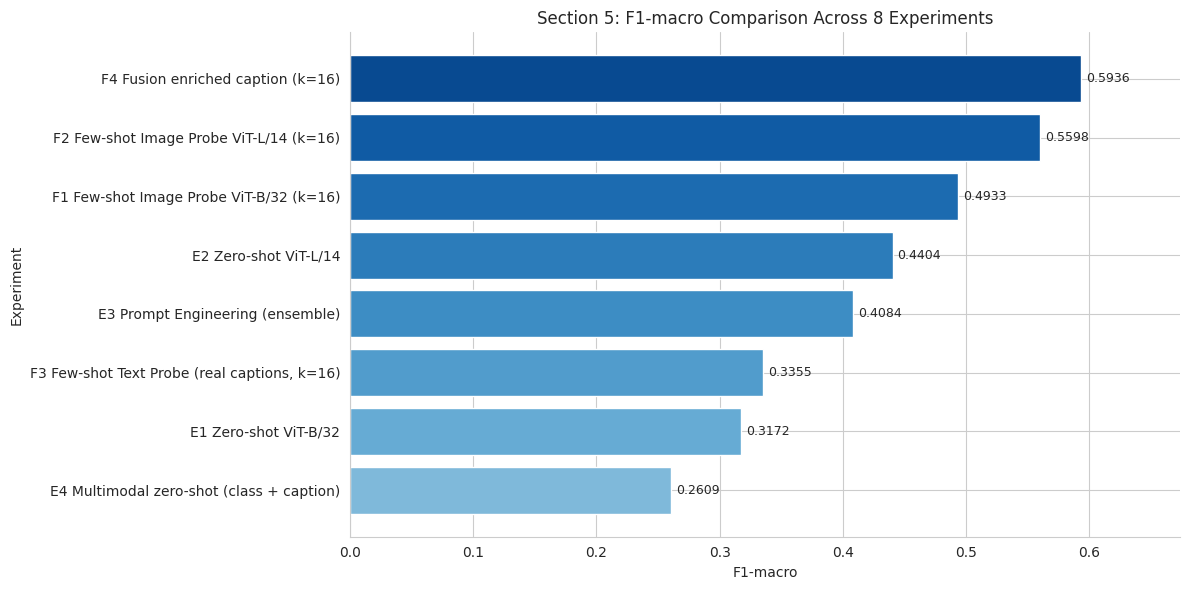

In [ ]:
# ============================================================
# Horizontal bar chart: compare 8 experiments by F1-macro
# ============================================================
plot_df = sec5_summary_df.sort_values("F1-macro", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(plot_df)))

bars = ax.barh(
    plot_df["Experiment"],
    plot_df["F1-macro"],
    color=colors
)

# show value on bar
for bar, val in zip(bars, plot_df["F1-macro"]):
    ax.text(
        val + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
    )

ax.set_title("Section 5: F1-macro Comparison Across 8 Experiments")
ax.set_xlabel("F1-macro")
ax.set_ylabel("Experiment")

ax.set_xlim(0, min(1.0, float(plot_df["F1-macro"].max() + 0.08)))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Sec 6 - Evaluation (Simplified)

Muc tieu: tong hop ket qua test set gon nhe, de theo doi nhanh.

- 6.0: Chay danh gia test set va tao `SEC6`.
- 6.1: In bang ket qua tong hop + model tot nhat.
- 6.2: Ve confusion matrix E1 vs best few-shot.
- 6.3, 6.4: Optional (da duoc rut gon).

In [ ]:
# ============================================================
# 6.0 - Retest Section 5 pipeline on TEST set (8 experiments)
# ============================================================
import time
import numpy as np
import pandas as pd
import torch
import clip

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# ---------- Sanity checks: this cell reuses Section 5 utilities ----------
required_globals = [
    "classes",
    "CONFIG",
    "DEVICE",
    "get_features",
    "zero_shot_classify",
    "encode_texts_batched",
    "run_few_shot_probe",
    "sample_k_shot_indices",
    "train_df",
    "val_df",
    "test_df",
]
missing_globals = [k for k in required_globals if k not in globals()]
if missing_globals:
    raise RuntimeError(
        f"Missing required objects from previous sections: {missing_globals}. "
        "Please run Section 5.0 first."
    )


def _metrics(y_true, y_pred):
    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def _best_k_from_curve(curve_dict, default_k=16):
    if not isinstance(curve_dict, dict) or len(curve_dict) == 0:
        return default_k
    return int(max(curve_dict.keys(), key=lambda k: curve_dict[k]["f1_mean"]))


def _fit_probe_predict(X_train_full, y_train, X_eval, k, seed=42):
    idx = sample_k_shot_indices(y_train, k, seed=seed)
    X_tr = X_train_full[idx]
    y_tr = y_train[idx]
    clf = LogisticRegression(
        max_iter=1000,
        C=0.316,
        random_state=seed,
        solver="lbfgs",
        multi_class="multinomial",
    )
    clf.fit(X_tr, y_tr)
    return clf.predict(X_eval)


KS = [1, 4, 8, 16]
N_RUNS = int(CONFIG.get("n_runs", 5))
SEED_BASE = int(CONFIG.get("random_seed", 42))

# ---------- Load features ----------
tr_b32 = get_features("ViT-B-32", "train")
ts_b32 = get_features("ViT-B-32", "test")
tr_l14 = get_features("ViT-L-14", "train")
ts_l14 = get_features("ViT-L-14", "test")

y_train_b32 = tr_b32["labels"].numpy()
y_train_l14 = tr_l14["labels"].numpy()
y_test = ts_b32["labels"].numpy()

X_train_img_b32 = tr_b32["img_features"].numpy()
X_test_img_b32 = ts_b32["img_features"].numpy()
X_train_img_l14 = tr_l14["img_features"].numpy()
X_test_img_l14 = ts_l14["img_features"].numpy()

X_train_text_real = tr_b32["text_features"].numpy()
X_test_text_real = ts_b32["text_features"].numpy()

PROMPT_SIMPLE = globals().get("PROMPT_SIMPLE", "a photo of {cls} clothing")
PROMPT_TEMPLATES = globals().get(
    "PROMPT_TEMPLATES",
    {
        "simple": "a photo of {cls}",
        "fashion": "a fashion photo of {cls} clothing",
        "detailed": "a photo of a person wearing {cls}",
        "context": "this is a {cls} garment",
    },
)

# ---------- E1 / E2: zero-shot image ----------
model_b32, _ = clip.load("ViT-B/32", device=DEVICE)
model_b32.eval()

start = time.perf_counter()
preds_e1_test = zero_shot_classify(ts_b32["img_features"], classes, PROMPT_SIMPLE, model_b32)
inf_e1 = (time.perf_counter() - start) / len(y_test) * 1000
m_e1 = _metrics(y_test, preds_e1_test)

model_l14, _ = clip.load("ViT-L/14", device=DEVICE)
model_l14.eval()

start = time.perf_counter()
preds_e2_test = zero_shot_classify(ts_l14["img_features"], classes, PROMPT_SIMPLE, model_l14)
inf_e2 = (time.perf_counter() - start) / len(y_test) * 1000
m_e2 = _metrics(y_test, preds_e2_test)

# ---------- E3: prompt engineering (use ensemble to match Section 5 summary) ----------
with torch.no_grad():
    all_class_embs = []
    for tmpl in PROMPT_TEMPLATES.values():
        prompts = [tmpl.format(cls=c.replace("_", " ").lower()) for c in classes]
        tokens = clip.tokenize(prompts, truncate=True).to(DEVICE)
        embs = model_b32.encode_text(tokens).float()
        embs = torch.nn.functional.normalize(embs, dim=-1)
        all_class_embs.append(embs)

    ensemble_emb = torch.stack(all_class_embs, dim=0).mean(dim=0)
    ensemble_emb = torch.nn.functional.normalize(ensemble_emb, dim=-1)
    sims = ts_b32["img_features"].to(DEVICE) @ ensemble_emb.T
    preds_e3_test = sims.argmax(dim=1).cpu().numpy()

m_e3 = _metrics(y_test, preds_e3_test)

# Keep prompt-name selection for downstream Section 8
best_template_name, best_template_f1 = None, -1.0
for name, tmpl in PROMPT_TEMPLATES.items():
    preds = zero_shot_classify(ts_b32["img_features"], classes, tmpl, model_b32)
    m = _metrics(y_test, preds)
    if m["f1_macro"] > best_template_f1:
        best_template_f1 = m["f1_macro"]
        best_template_name = name

# ---------- E4: multimodal zero-shot ----------
if "multimodal_zero_shot_with_caption" in globals():
    test_captions = test_df["caption"].astype(str).tolist()
    start = time.perf_counter()
    preds_e4_test = multimodal_zero_shot_with_caption(
        img_features=ts_b32["img_features"],
        captions=test_captions,
        class_names=classes,
        model=model_b32,
        device=DEVICE,
    )
    inf_e4 = (time.perf_counter() - start) / len(y_test) * 1000
else:
    test_captions = test_df["caption"].astype(str).tolist()

    @torch.no_grad()
    def _mm_zero_shot_fallback(img_features, captions, class_names, model, device=DEVICE):
        class_text = [c.replace("_", " ").lower() for c in class_names]
        n = len(captions)
        c = len(class_names)
        all_prompts = []
        for cap in captions:
            all_prompts.extend([f"a photo of {cls} clothing. {str(cap)}" for cls in class_text])
        txt_emb = encode_texts_batched(all_prompts, model=model, batch_size=512, device=device)
        txt_emb = txt_emb.view(n, c, -1).to(device)
        img = img_features.to(device).unsqueeze(1)
        sims = (img * txt_emb).sum(dim=-1)
        return sims.argmax(dim=1).cpu().numpy()

    start = time.perf_counter()
    preds_e4_test = _mm_zero_shot_fallback(ts_b32["img_features"], test_captions, classes, model_b32, device=DEVICE)
    inf_e4 = (time.perf_counter() - start) / len(y_test) * 1000

m_e4 = _metrics(y_test, preds_e4_test)

# ---------- F1 / F2 / F3 / F4: few-shot retest on TEST ----------
F1_test_curve = run_few_shot_probe(
    X_train_full=X_train_img_b32,
    y_train=y_train_b32,
    X_val=X_test_img_b32,
    y_val=y_test,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

F2_test_curve = run_few_shot_probe(
    X_train_full=X_train_img_l14,
    y_train=y_train_l14,
    X_val=X_test_img_l14,
    y_val=ts_l14["labels"].numpy(),
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

model_f3, _ = clip.load("ViT-B/32", device=DEVICE)
model_f3.eval()
syn_template = "a fashion photo of {cls} clothing"
class_prompts = [syn_template.format(cls=c.replace("_", " ").lower()) for c in classes]
class_prompt_emb = encode_texts_batched(class_prompts, model_f3, batch_size=64, device=DEVICE).numpy()
X_train_text_syn = class_prompt_emb[y_train_b32]

F3_syn_test_curve = run_few_shot_probe(
    X_train_full=X_train_text_syn,
    y_train=y_train_b32,
    X_val=X_test_text_real,
    y_val=y_test,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

F3_real_test_curve = run_few_shot_probe(
    X_train_full=X_train_text_real,
    y_train=y_train_b32,
    X_val=X_test_text_real,
    y_val=y_test,
    ks=KS,
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

del model_f3

model_f4, _ = clip.load("ViT-B/32", device=DEVICE)
model_f4.eval()
train_enriched_text = [
    f"{cap} This is {cls.replace('_', ' ').lower()} clothing."
    for cap, cls in zip(train_df["caption"].astype(str).tolist(), train_df["class"].astype(str).tolist())
]
test_enriched_text = [
    f"{cap} This is {cls.replace('_', ' ').lower()} clothing."
    for cap, cls in zip(test_df["caption"].astype(str).tolist(), test_df["class"].astype(str).tolist())
]

train_enriched_emb = encode_texts_batched(train_enriched_text, model_f4, batch_size=256, device=DEVICE)
test_enriched_emb = encode_texts_batched(test_enriched_text, model_f4, batch_size=256, device=DEVICE)

X_train_fused = torch.cat([tr_b32["img_features"], train_enriched_emb], dim=1).numpy()
X_test_fused = torch.cat([ts_b32["img_features"], test_enriched_emb], dim=1).numpy()

F4_test_curve = run_few_shot_probe(
    X_train_full=X_train_fused,
    y_train=y_train_b32,
    X_val=X_test_fused,
    y_val=y_test,
    ks=[4, 16],
    n_runs=N_RUNS,
    seed_base=SEED_BASE,
)

del model_f4

if DEVICE == "cuda":
    torch.cuda.empty_cache()

# ---------- Pick best k and derive concrete predictions ----------
best_k_f1 = _best_k_from_curve(F1_test_curve, default_k=16)
best_k_f2 = _best_k_from_curve(F2_test_curve, default_k=16)
best_k_f3 = _best_k_from_curve(F3_real_test_curve, default_k=16)
best_k_f4 = _best_k_from_curve(F4_test_curve, default_k=16)

preds_f1_test = _fit_probe_predict(X_train_img_b32, y_train_b32, X_test_img_b32, best_k_f1, seed=SEED_BASE)
preds_f2_test = _fit_probe_predict(X_train_img_l14, y_train_l14, X_test_img_l14, best_k_f2, seed=SEED_BASE)
preds_f3_test = _fit_probe_predict(X_train_text_real, y_train_b32, X_test_text_real, best_k_f3, seed=SEED_BASE)
preds_f4_test = _fit_probe_predict(X_train_fused, y_train_b32, X_test_fused, best_k_f4, seed=SEED_BASE)

# ---------- Build Section 6 outputs (same 8 experiment names as Section 5) ----------
summary_rows = [
    {
        "Experiment": "E1 Zero-shot ViT-B/32",
        "Accuracy": m_e1["acc"],
        "F1-macro": m_e1["f1_macro"],
        "F1-weighted": m_e1["f1_weighted"],
        "Inference(ms/sample)": inf_e1,
    },
    {
        "Experiment": "E2 Zero-shot ViT-L/14",
        "Accuracy": m_e2["acc"],
        "F1-macro": m_e2["f1_macro"],
        "F1-weighted": m_e2["f1_weighted"],
        "Inference(ms/sample)": inf_e2,
    },
    {
        "Experiment": "E3 Prompt Engineering (ensemble)",
        "Accuracy": m_e3["acc"],
        "F1-macro": m_e3["f1_macro"],
        "F1-weighted": m_e3["f1_weighted"],
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": "E4 Multimodal zero-shot (class + caption)",
        "Accuracy": m_e4["acc"],
        "F1-macro": m_e4["f1_macro"],
        "F1-weighted": m_e4["f1_weighted"],
        "Inference(ms/sample)": inf_e4,
    },
    {
        "Experiment": f"F1 Few-shot Image Probe ViT-B/32 (k={best_k_f1})",
        "Accuracy": F1_test_curve[best_k_f1]["acc_mean"],
        "F1-macro": F1_test_curve[best_k_f1]["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F2 Few-shot Image Probe ViT-L/14 (k={best_k_f2})",
        "Accuracy": F2_test_curve[best_k_f2]["acc_mean"],
        "F1-macro": F2_test_curve[best_k_f2]["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F3 Few-shot Text Probe (real captions, k={best_k_f3})",
        "Accuracy": F3_real_test_curve[best_k_f3]["acc_mean"],
        "F1-macro": F3_real_test_curve[best_k_f3]["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
    {
        "Experiment": f"F4 Fusion enriched caption (k={best_k_f4})",
        "Accuracy": F4_test_curve[best_k_f4]["acc_mean"],
        "F1-macro": F4_test_curve[best_k_f4]["f1_mean"],
        "F1-weighted": np.nan,
        "Inference(ms/sample)": np.nan,
    },
]

SEC6 = {}
SEC6["selection_metric"] = "f1_macro"
SEC6["best_prompt_name"] = best_template_name
SEC6["best_k"] = {
    "F1": int(best_k_f1),
    "F2": int(best_k_f2),
    "F3": int(best_k_f3),
    "F4": int(best_k_f4),
}
SEC6["y_test"] = y_test
SEC6["summary_df"] = pd.DataFrame(summary_rows)
SEC6["curves"] = {
    "F1": F1_test_curve,
    "F2": F2_test_curve,
    "F3": F3_real_test_curve,
    "F3_synthetic": F3_syn_test_curve,
    "F4": F4_test_curve,
}
SEC6["preds"] = {
    "E1": preds_e1_test,
    "E2": preds_e2_test,
    "E3": preds_e3_test,
    "E4": preds_e4_test,
    "F1": preds_f1_test,
    "F2": preds_f2_test,
    "F3": preds_f3_test,
    "F4": preds_f4_test,
}

print("Sec 6.0 now retests all 8 Section 5 experiments on TEST set.")
print("Experiments in Section 6: E1, E2, E3, E4, F1, F2, F3, F4")
print(f"Best prompt on TEST by F1-macro (E3 templates): {best_template_name}")
print(f"Best k on TEST by F1-macro: F1={best_k_f1}, F2={best_k_f2}, F3={best_k_f3}, F4={best_k_f4}")

Sec 6.0 now retests all 8 Section 5 experiments on TEST set.
Experiments in Section 6: E1, E2, E3, E4, F1, F2, F3, F4
Best prompt on TEST by F1-macro (E3 templates): detailed
Best k on TEST by F1-macro: F1=16, F2=16, F3=16, F4=16


Sec 6 summary (test set):


,Experiment,Accuracy,F1-macro,F1-weighted,Inference(ms/sample)
0,F4 Fusion enriched caption (k=16),0.6612,0.5886,nan,nan
1,F2 Few-shot Image Probe ViT-L/14 (k=16),0.6069,0.5549,nan,nan
2,F1 Few-shot Image Probe ViT-B/32 (k=16),0.5370,0.4903,nan,nan
3,E2 Zero-shot ViT-L/14,0.4994,0.4340,0.5194,0.0036
4,E3 Prompt Engineering (ensemble),0.4594,0.3893,0.4329,nan
5,"F3 Few-shot Text Probe (real captions, k=16)",0.3841,0.3289,nan,nan
6,E1 Zero-shot ViT-B/32,0.3857,0.2974,0.3183,0.0032
7,E4 Multimodal zero-shot (class + caption),0.3146,0.2721,0.3471,5.4888



Best model on test set:
  Experiment: F4 Fusion enriched caption (k=16)
  Selection : F1-macro
  Accuracy  : 0.6612
  F1-macro  : 0.5886


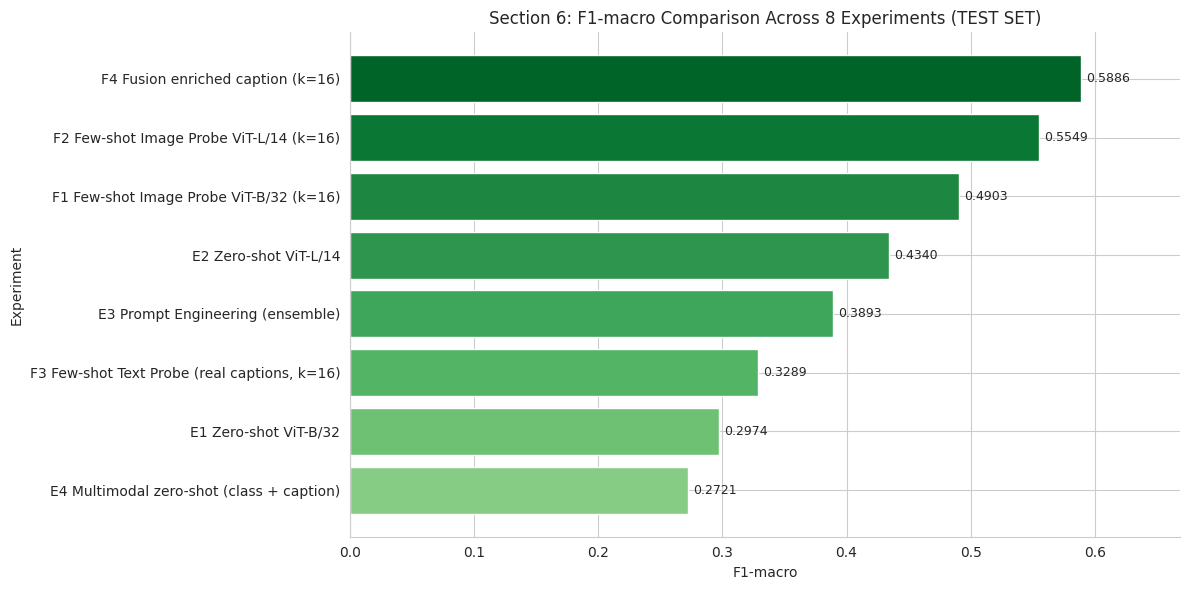

In [ ]:
# ============================================================
# 6.1 - Compact test summary (table + best model + plot)
# ============================================================
if "SEC6" not in globals() or "summary_df" not in SEC6:
    raise RuntimeError("SEC6 summary not found. Please run 6.0 first.")

summary_df = SEC6["summary_df"].copy().sort_values("F1-macro", ascending=False).reset_index(drop=True)
SEC6["summary_df"] = summary_df

best_row = summary_df.iloc[0].to_dict()
SEC6["best_model"] = best_row
SEC6["selection_metric"] = "f1_macro"

print("Sec 6 summary (test set):")
display(summary_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-macro": "{:.4f}",
    "F1-weighted": "{:.4f}",
    "Inference(ms/sample)": "{:.4f}",
}))

print("\nBest model on test set:")
print(f"  Experiment: {best_row['Experiment']}")
print("  Selection : F1-macro")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  F1-macro  : {best_row['F1-macro']:.4f}")

# --- Visualization: F1-macro comparison ---
plot_df = summary_df.sort_values("F1-macro", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Greens(np.linspace(0.45, 0.9, len(plot_df)))

bars = ax.barh(
    plot_df["Experiment"],
    plot_df["F1-macro"],
    color=colors
)

# show value on bar
for bar, val in zip(bars, plot_df["F1-macro"]):
    if not np.isnan(val):
        ax.text(
            val + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

ax.set_title("Section 6: F1-macro Comparison Across 8 Experiments (TEST SET)")
ax.set_xlabel("F1-macro")
ax.set_ylabel("Experiment")

max_val = plot_df["F1-macro"].max()
ax.set_xlim(0, min(1.0, float(max_val + 0.08)))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Few-shot F1-macro: {'F1': 0.4903, 'F2': 0.5549, 'F3': 0.3289, 'F4': 0.5886}
Selected best few-shot: F4 (k=16)


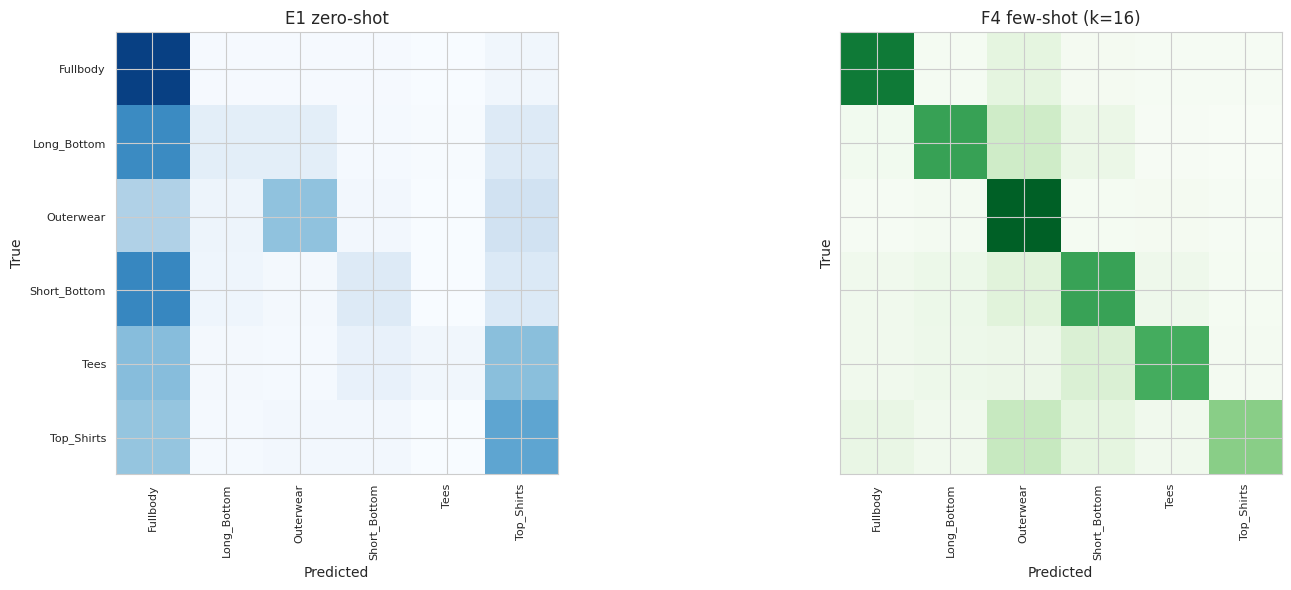

In [ ]:
# ============================================================
# 6.2 - Confusion matrix (minimal): E1 vs best few-shot
# ============================================================
from sklearn.metrics import confusion_matrix

if "SEC6" not in globals():
    raise RuntimeError("SEC6 not found. Please run 6.0 first.")

y_true = SEC6["y_test"]
preds_e1 = SEC6["preds"]["E1"]

cand_keys = ["F1", "F2", "F3", "F4"]
f1_map = {k: SEC6["curves"][k][SEC6["best_k"][k]]["f1_mean"] for k in cand_keys}
best_fs_key = max(f1_map, key=f1_map.get)
best_fs_k = SEC6["best_k"][best_fs_key]
preds_best_fs = SEC6["preds"][best_fs_key]

SEC6["best_fewshot_key"] = best_fs_key
SEC6["best_fewshot_k"] = int(best_fs_k)

label_names = [idx2class[i] if "idx2class" in globals() else classes[i] for i in range(len(classes))]
cm_e1 = confusion_matrix(y_true, preds_e1, labels=np.arange(len(classes)), normalize="true")
cm_fs = confusion_matrix(y_true, preds_best_fs, labels=np.arange(len(classes)), normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
axes[0].imshow(cm_e1, cmap="Blues", vmin=0, vmax=1)
axes[1].imshow(cm_fs, cmap="Greens", vmin=0, vmax=1)

titles = ["E1 zero-shot", f"{best_fs_key} few-shot (k={best_fs_k})"]
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))
    ax.set_xticklabels(label_names, rotation=90, fontsize=8)
    ax.set_yticklabels(label_names, fontsize=8)

print("Few-shot F1-macro:", {k: round(v, 4) for k, v in f1_map.items()})
print(f"Selected best few-shot: {best_fs_key} (k={best_fs_k})")
plt.tight_layout()
plt.show()

## Sec 6.5 · Kết luận thử nghiệm (chuẩn hóa)

- Mọi quyết định chọn mô hình đều ưu tiên **F1-macro** để nhất quán với mục tiêu phân loại đa lớp.
- Bảng tổng hợp ở Section 5 (validation) và Section 6 (test) dùng cùng cấu trúc chỉ số: **Accuracy, F1-macro, F1-weighted, Inference(ms/sample)**.
- Với các mô hình few-shot (F1-F4), k được chọn theo **F1-macro cao nhất** và được ghi rõ trực tiếp trong tên thí nghiệm.
- Section 6 là nguồn kết luận cuối cùng cho test set; Section 5 chỉ dùng để so sánh/chọn cấu hình trên validation.

**Kết luận ngắn:** dùng cùng một rule chọn mô hình theo F1-macro giúp so sánh công bằng hơn giữa zero-shot và few-shot, đồng thời tránh lệch khi dữ liệu có mất cân bằng lớp.

## Sec 8 - Single Styled Attention Output

This section is reduced to one final styled output:
- two attention overlays side by side
- highlighted caption tokens below the images

Run the Section 8 setup cell first, then run the styled output cell.

In [ ]:
# ============================================================
# 8.0 – Setup: err_df, attention hooks, shared helpers
# ============================================================
import os
import types
import textwrap
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from collections import Counter

# ── Dependency guard ────────────────────────────────────────────────────────
_required = ["SEC6", "test_df", "classes", "idx2class", "CONFIG", "clip"]
_missing  = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(f"Missing: {_missing}. Run earlier sections first.")
if "y_test" not in SEC6 or "preds" not in SEC6:
    raise RuntimeError("SEC6 missing y_test / preds. Re-run Section 6.0.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLIP_MEAN = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)
CLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)

if "PROMPT_TEMPLATES" not in globals():
    PROMPT_TEMPLATES = {
        "simple":   "a photo of {cls}",
        "fashion":  "a fashion photo of {cls} clothing",
        "detailed": "a photo of a person wearing {cls}",
        "context":  "this is a {cls} garment",
    }

best_prompt_name     = SEC6.get("best_prompt_name", "detailed")
best_prompt_template = PROMPT_TEMPLATES.get(best_prompt_name, "a photo of {cls} clothing")

# ── Build err_df ─────────────────────────────────────────────────────────────
y_true = np.asarray(SEC6["y_test"])
_cand  = [k for k in ["F1", "F2", "F3", "F4"] if k in SEC6.get("preds", {})]
if not _cand:
    raise RuntimeError("SEC6['preds'] has no F1/F2/F3/F4.")

if "best_fewshot_key" in SEC6 and SEC6["best_fewshot_key"] in _cand:
    best_fs_key = SEC6["best_fewshot_key"]
elif "curves" in SEC6 and "best_k" in SEC6:
    _f1 = {k: SEC6["curves"][k][SEC6["best_k"][k]]["f1_mean"] for k in _cand
           if k in SEC6["curves"] and SEC6["best_k"].get(k) in SEC6["curves"].get(k, {})}
    best_fs_key = max(_f1, key=_f1.get) if _f1 else _cand[0]
else:
    _acc = {k: float((np.asarray(SEC6["preds"][k]) == y_true).mean()) for k in _cand}
    best_fs_key = max(_acc, key=_acc.get)

err_df = test_df.copy().reset_index(drop=True)
err_df["true_label"] = y_true
for _key in ["E1", "E2", "E3"] + _cand:
    if _key in SEC6["preds"]:
        err_df[f"pred_{_key.lower()}"] = np.asarray(SEC6["preds"][_key])
        err_df[f"pred_class_{_key.lower()}"] = err_df[f"pred_{_key.lower()}"].map(idx2class)
err_df["true_class"] = err_df["true_label"].map(idx2class)

# ── Attention helpers ─────────────────────────────────────────────────────────
def patch_attention(clip_model):
    blocks = clip_model.visual.transformer.resblocks
    originals = [b.attention for b in blocks]
    for block in blocks:
        def _patched(self, x):
            mask = self.attn_mask
            if mask is not None:
                mask = mask.to(dtype=x.dtype, device=x.device)
            out, attn = self.attn(x, x, x,
                                  need_weights=True,
                                  average_attn_weights=False,
                                  attn_mask=mask)
            self.last_attn = attn          # [B, heads, T, T]
            return out
        block.attention = types.MethodType(_patched, block)
    return blocks, originals

def restore_attention(blocks, originals):
    for b, fn in zip(blocks, originals):
        b.attention = fn

def attention_rollout(blocks):
    maps = [b.last_attn.detach().mean(1) for b in blocks if hasattr(b, "last_attn")]
    if not maps:
        raise RuntimeError("No attention maps collected.")
    A = torch.stack(maps)                             # [L, B, T, T]
    B, T = A.shape[1], A.shape[2]
    eye = torch.eye(T, device=A.device).unsqueeze(0).unsqueeze(0)
    A   = (A + eye) / ((A + eye).sum(-1, keepdim=True) + 1e-8)
    R   = torch.eye(T, device=A.device).unsqueeze(0).repeat(B, 1, 1)
    for l in range(A.shape[0]):
        R = A[l] @ R
    return R[:, 0, 1:]                                # CLS→patch scores

def norm01(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def overlay_attn(img_rgb, attn_map, alpha=0.45):
    h, w = img_rgb.shape[:2]
    heat = np.array(
        Image.fromarray((attn_map * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR),
        dtype=np.float32) / 255.0
    heat_rgb = plt.get_cmap("jet")(heat)[..., :3]
    return np.clip((1 - alpha) * img_rgb + alpha * heat_rgb, 0, 1)

def caption_token_importance(caption, model, prompt_template, target_idx):
    cls_emb = F.normalize(
        model.encode_text(clip.tokenize(
            [prompt_template.format(cls=c.replace("_", " ").lower()) for c in classes]
        ).to(DEVICE)).float(), dim=-1)

    @torch.no_grad()
    def _score(txt):
        tok = clip.tokenize([txt], truncate=True).to(DEVICE)
        emb = F.normalize(model.encode_text(tok).float(), dim=-1)
        return float((emb @ cls_emb.T)[0, target_idx].item())

    words = str(caption).split()
    if not words:
        return [], np.array([], dtype=np.float32)
    base = _score(" ".join(words))
    scores = [base - (_score(" ".join(words[:i] + words[i+1:])) if len(words) > 1 else 0.0)
              for i in range(len(words))]
    return words, np.asarray(scores, dtype=np.float32)

# ── Store in SEC8 ─────────────────────────────────────────────────────────────
SEC8 = globals().get("SEC8", {})
SEC8.update({"err_df": err_df, "best_fewshot_key": best_fs_key,
             "best_prompt_name": best_prompt_name})
globals()["SEC8"] = SEC8

print("✓ Section 8 setup complete")
print(f"  Device             : {DEVICE}")
print(f"  Best prompt (E3)   : {best_prompt_name}")
print(f"  Best few-shot key  : {best_fs_key}")
print(f"  Test samples       : {len(err_df):,}")
print(f"  Experiments found  : {list(SEC6['preds'].keys())}")

✓ Section 8 setup complete
  Device             : cuda
  Best prompt (E3)   : detailed
  Best few-shot key  : F4
  Test samples       : 8,506
  Experiments found  : ['E1', 'E2', 'E3', 'E4', 'F1', 'F2', 'F3', 'F4']


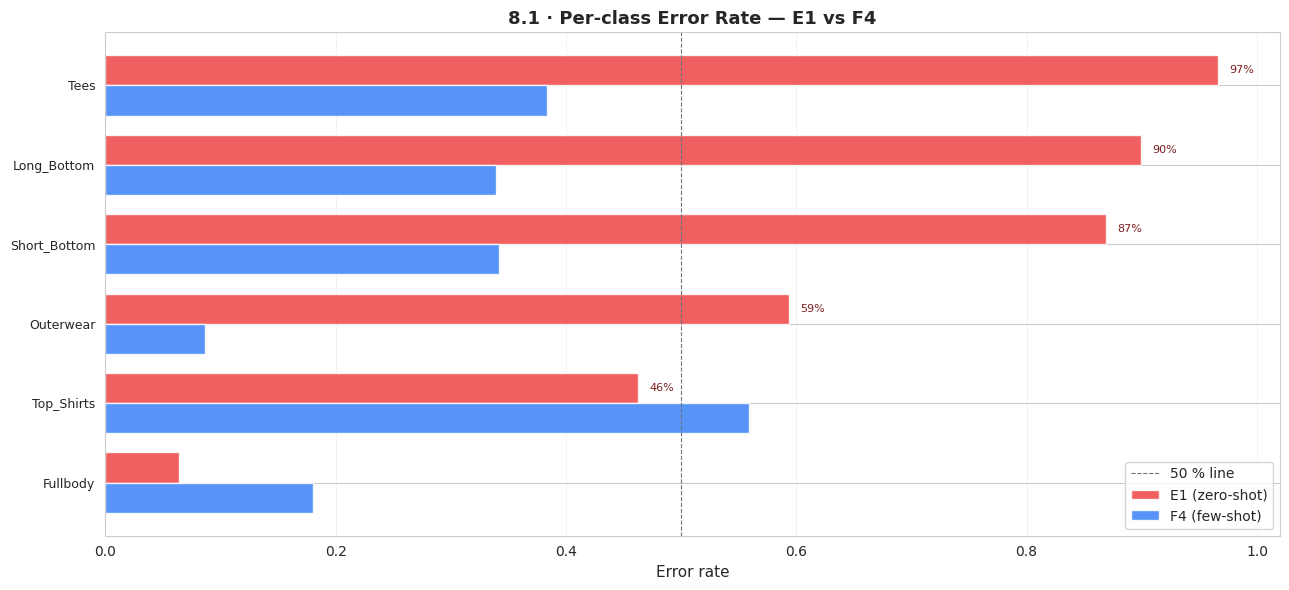


Class                              n   E1 err%     F4 err%
------------------------------------------------------------
Tees                            2890    96.6%       38.3%
Long_Bottom                      218    89.9%       33.9%
Short_Bottom                     465    86.9%       34.2%
Outerwear                       1653    59.3%        8.7%
Top_Shirts                      1614    46.2%       55.9%
Fullbody                        1666     6.4%       18.1%


In [ ]:
# ============================================================
# 8.1 – Per-class error rate  (sorted worst → best, two experiments)
# ============================================================
if "SEC8" not in globals() or "err_df" not in SEC8:
    raise RuntimeError("Run 8.0 first.")

err_df   = SEC8["err_df"]
best_key = SEC8["best_fewshot_key"].lower()   # e.g. "f4"

def class_error_rates(err_df, pred_col):
    rows = []
    for cls, grp in err_df.groupby("true_class"):
        n_total = len(grp)
        n_err   = (grp["true_label"] != grp[pred_col]).sum()
        rows.append({"class": cls, "n_total": n_total,
                     "n_error": int(n_err), "error_rate": n_err / max(n_total, 1)})
    return pd.DataFrame(rows).sort_values("error_rate", ascending=False).reset_index(drop=True)

col_e1   = "pred_e1"
col_best = f"pred_{best_key}"

if col_e1 not in err_df.columns:
    raise RuntimeError(f"Column '{col_e1}' not found in err_df.")
if col_best not in err_df.columns:
    raise RuntimeError(f"Column '{col_best}' not found in err_df.")

df_e1   = class_error_rates(err_df, col_e1)
df_best = class_error_rates(err_df, col_best)

# Merge on class, sort by E1 error rate
merged = df_e1.rename(columns={"error_rate": "E1", "n_error": "n_err_e1"})               .merge(df_best[["class", "error_rate"]].rename(columns={"error_rate": best_key.upper()}),
                     on="class")
merged = merged.sort_values("E1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, max(6, len(merged) * 0.38)))
y_pos = np.arange(len(merged))
width = 0.38

bars_e1   = ax.barh(y_pos + width/2, merged["E1"],   width, label="E1 (zero-shot)",
                    color="#ef4444", alpha=0.85)
bars_best = ax.barh(y_pos - width/2, merged[best_key.upper()], width,
                    label=f"{best_key.upper()} (few-shot)", color="#3b82f6", alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(merged["class"], fontsize=9)
ax.set_xlabel("Error rate", fontsize=11)
ax.set_title("8.1 · Per-class Error Rate — E1 vs " + best_key.upper(), fontsize=13, fontweight="bold")
ax.axvline(0.5, color="#6b7280", linewidth=0.8, linestyle="--", label="50 % line")
ax.set_xlim(0, 1.02)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3, linewidth=0.6)

# Annotate worst 5
for i in y_pos[-5:]:
    ax.text(merged.loc[i, "E1"] + 0.01, i + width/2,
            f'{merged.loc[i, "E1"]:.0%}', va="center", fontsize=8, color="#7f1d1d")

plt.tight_layout()
plt.show()

print(f"\n{'Class':<30} {'n':>5}  {'E1 err%':>8}  {best_key.upper()+' err%':>10}")
print("-" * 60)
for _, row in merged.iloc[::-1].iterrows():
    print(f"{row['class']:<30} {int(row['n_total']):>5}  "
          f"{row['E1']:>7.1%}  {row[best_key.upper()]:>10.1%}")

In [ ]:
# ============================================================
# 8.2 – Top confused class pairs  (row-normalised confusion heatmap)
# ============================================================
from sklearn.metrics import confusion_matrix

if "SEC8" not in globals():
    raise RuntimeError("Run 8.0 first.")

err_df   = SEC8["err_df"]
best_key = SEC8["best_fewshot_key"].lower()
col_e1   = "pred_e1"
col_best = f"pred_{best_key}"

class_names   = sorted(err_df["true_class"].dropna().unique())
n_cls         = len(class_names)
cls2idx_local = {c: i for i, c in enumerate(class_names)}

def row_norm_cm(true_col, pred_col):
    """Build confusion matrix, safely ignoring NaN / unmapped predictions."""
    tmp = err_df[[true_col, pred_col]].copy()
    tmp = tmp.dropna(subset=[true_col, pred_col])          # drop NaN rows
    yt  = tmp[true_col].map(cls2idx_local)
    yp  = tmp[pred_col].map(cls2idx_local)
    # Drop rows where class name wasn't found in cls2idx_local
    valid = yt.notna() & yp.notna()
    yt    = yt[valid].astype(int).values
    yp    = yp[valid].astype(int).values
    if len(yt) == 0:
        raise RuntimeError(f"No valid rows for columns '{true_col}' / '{pred_col}'.")
    cm = confusion_matrix(yt, yp, labels=list(range(n_cls)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    return cm, cm_norm

cm_e1,   cm_e1_norm   = row_norm_cm("true_class", col_e1)
cm_best, cm_best_norm = row_norm_cm("true_class", col_best)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
tick_labels = [c.replace("_", " ") for c in class_names]

for ax, cm_norm, cm_raw, title in [
    (axes[0], cm_e1_norm,   cm_e1,   "E1  ·  Zero-shot (ViT-B/32)"),
    (axes[1], cm_best_norm, cm_best, f"{best_key.upper()}  ·  Few-shot (best)"),
]:
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(n_cls))
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7.5)
    ax.set_yticks(range(n_cls))
    ax.set_yticklabels(tick_labels, fontsize=7.5)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True",      fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    for i in range(n_cls):
        for j in range(n_cls):
            val = cm_norm[i, j]
            if val > 0.05:
                color = "white" if val > 0.55 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color=color,
                        fontweight="bold" if i == j else "normal")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

plt.suptitle("8.2 · Row-normalised Confusion Matrix",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Top-10 confused pairs (E1, off-diagonal)
print("\nTop-10 confused pairs (E1 — off-diagonal, by raw count):")
print(f"{'True':<28} {'Predicted':<28} {'Count':>6}  {'Rate':>6}")
print("-" * 72)
pairs = [(class_names[i], class_names[j], int(cm_e1[i, j]), cm_e1_norm[i, j])
         for i in range(n_cls) for j in range(n_cls) if i != j and cm_e1[i, j] > 0]
pairs.sort(key=lambda x: -x[2])
for tc, pc, cnt, rate in pairs[:10]:
    print(f"  {tc:<26} → {pc:<26} {cnt:>6}  {rate:>5.1%}")

SEC8["cm_e1"]          = cm_e1
SEC8["cm_best"]        = cm_best
SEC8["class_names_cm"] = class_names
globals()["SEC8"] = SEC8

RuntimeError: No valid rows for columns 'true_class' / 'pred_e1'.

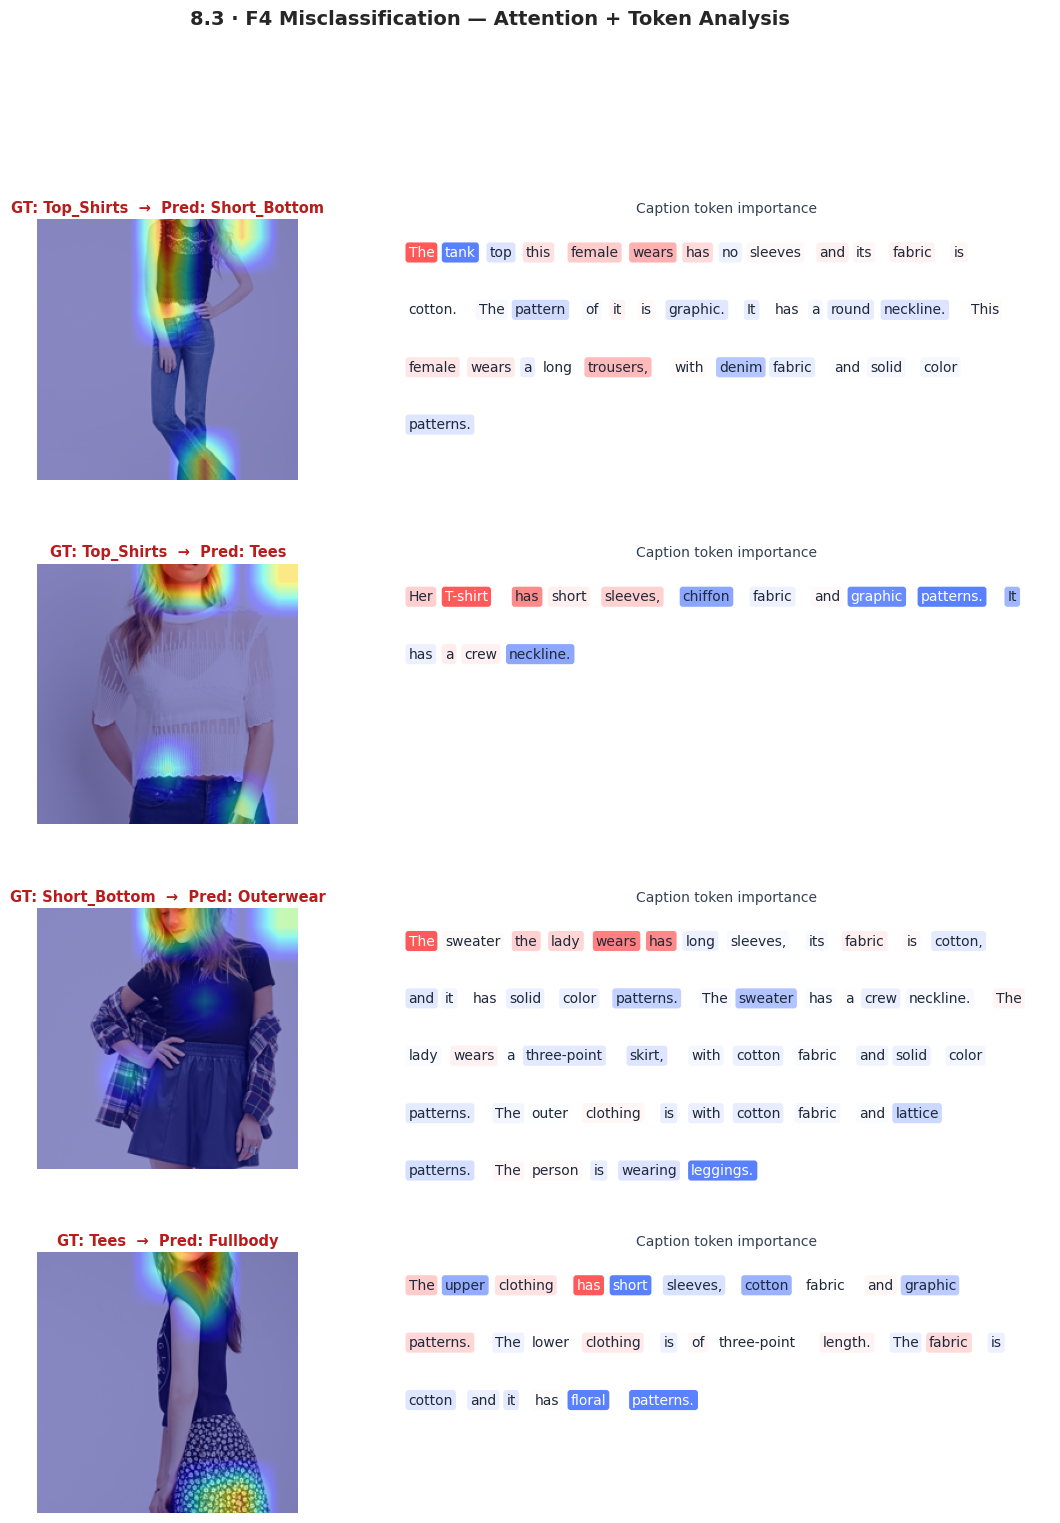

✓ Done — 4 samples.


In [ ]:
# ============================================================
# 8.3 – 4 misclassified samples: attention map + token highlight
# ============================================================
MAX_SAMPLES = 4

if "SEC8" not in globals():
    raise RuntimeError("Run 8.0 first.")
if "F4" not in SEC6.get("preds", {}):
    raise RuntimeError("SEC6['preds']['F4'] missing.")

best_prompt_tmpl = PROMPT_TEMPLATES.get(SEC8["best_prompt_name"], "a photo of {cls} clothing")
y_true_np  = np.asarray(SEC6["y_test"])
y_pred_f4  = np.asarray(SEC6["preds"]["F4"])
mis_indices = np.where(y_pred_f4 != y_true_np)[0][:MAX_SAMPLES]

if len(mis_indices) == 0:
    raise RuntimeError("No F4 misclassified samples found.")

# ── Token colour helper (SWAPPED RED AND BLUE) ───────────────────────────────
def token_color(s, pos_max, neg_min):
    if s > 0:
        # Original Blue -> Now Red
        t = min(s / max(pos_max, 1e-8), 1.0)
        return (1.0, 1 - 0.72*t, 1 - 0.72*t)
    else:
        # Original Red -> Now Blue
        t = min(abs(s) / max(abs(neg_min), 1e-8), 1.0)
        return (1 - 0.72*t, 1 - 0.55*t, 1.0)

def draw_tokens(ax, words, scores, font_size=10):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    if not len(words):
        return
    pos_max = max(scores.max(), 1e-8)
    neg_min = min(scores.min(), -1e-8)
    char_w, pad = 0.013, 0.006
    x, y = 0.01, 0.90
    line_h = 0.22
    for word, sc in zip(words, scores):
        fc = token_color(sc, pos_max, neg_min)
        bright = 0.299*fc[0] + 0.587*fc[1] + 0.114*fc[2]
        tc = "#1e293b" if bright > 0.6 else "white"
        w_width = len(word) * char_w + pad * 2
        if x + w_width > 0.98:
            x = 0.01; y -= line_h
        if y < 0.02:
            break
        ax.text(x, y, word, transform=ax.transAxes,
                fontsize=font_size, va="top", color=tc,
                bbox=dict(boxstyle="round,pad=0.22", facecolor=fc,
                          edgecolor="none", alpha=0.90))
        x += w_width + 0.005

# ── Load model ───────────────────────────────────────────────────────────────
clip_b32, preprocess_b32 = clip.load("ViT-B/32", device=DEVICE)
clip_b32.eval()
blocks, originals = patch_attention(clip_b32)

# ── One figure: 4 rows × 2 cols [attention | tokens] ─────────────────────────
fig, axes = plt.subplots(MAX_SAMPLES, 2,
                         figsize=(14, 4.2 * MAX_SAMPLES),
                         gridspec_kw={"width_ratios": [1, 1.6], "wspace": 0.06, "hspace": 0.32})

try:
    for row, idx in enumerate(mis_indices):
        true_name = idx2class[int(y_true_np[idx])]
        pred_name = idx2class[int(y_pred_f4[idx])]
        caption   = str(test_df.iloc[idx]["caption"])
        img_path  = os.path.join(CONFIG["image_dir"], str(test_df.iloc[idx]["img_name"]))

        # Forward pass
        with Image.open(img_path).convert("RGB") as pil:
            x = preprocess_b32(pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _ = clip_b32.encode_image(x)

        # Attention rollout (enhanced: max + top-10% mask)
        layer_maps = [b.last_attn.detach().mean(1)[0].cpu().numpy()
                      for b in blocks if hasattr(b, "last_attn")]
        cls_tok = np.stack([a[0, 1:] for a in layer_maps])
        g = int(np.floor(np.sqrt(cls_tok.shape[1])))
        raw = cls_tok.max(0)[:g*g]
        thr = np.quantile(raw, 0.90)
        attn = norm01(np.where(raw >= thr, raw, 0.0).reshape(g, g))

        img_np = np.clip(CLIP_STD * x[0].cpu().numpy().transpose(1,2,0) + CLIP_MEAN, 0, 1)
        overlay = overlay_attn(img_np, attn, alpha=0.45)

        # Token importance
        words, scores = caption_token_importance(
            caption, clip_b32, best_prompt_tmpl, target_idx=int(y_pred_f4[idx]))

        # ── Left: attention image ─────────────────────────────────────────────
        ax_img = axes[row, 0]
        ax_img.imshow(overlay); ax_img.axis("off")
        ax_img.set_title(
            f"GT: {true_name}  →  Pred: {pred_name}",
            fontsize=10.5, fontweight="bold",
            color="#b91c1c", pad=5)

        # ── Right: token panel ────────────────────────────────────────────────
        ax_tok = axes[row, 1]
        ax_tok.set_facecolor("#f8fafc")
        draw_tokens(ax_tok, words, scores, font_size=10)
        ax_tok.set_title("Caption token importance", fontsize=10,
                         color="#334155", pad=5)

finally:
    restore_attention(blocks, originals)
    del clip_b32
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

fig.suptitle("8.3 · F4 Misclassification — Attention + Token Analysis",
             fontsize=14, fontweight="bold", y=1.005)
plt.show()
print(f"✓ Done — {len(mis_indices)} samples.")

In [ ]:
# ============================================================
# 8.4 – Error summary table  (per-experiment + dominant confusion)
# ============================================================
if "SEC8" not in globals():
    raise RuntimeError("Run 8.0 first.")

err_df     = SEC8["err_df"]
cm_e1      = SEC8.get("cm_e1")
cm_best    = SEC8.get("cm_best")
cls_names  = SEC8.get("class_names_cm", sorted(err_df["true_class"].unique()))
best_key   = SEC8["best_fewshot_key"]

rows = []
for exp_key in ["E1", "E2", "E3"] + [k for k in ["F1", "F2", "F3", "F4"]
                                       if k in SEC6.get("preds", {})]:
    col = f"pred_{exp_key.lower()}"
    if col not in err_df.columns:
        continue
    n_total = len(err_df)
    n_err   = (err_df["true_label"] != err_df[col]).sum()
    acc     = 1 - n_err / n_total

    # Dominant off-diagonal pair
    yt = err_df["true_class"].map({c: i for i, c in enumerate(cls_names)}).values
    yp = err_df[col].map({c: i for i, c in enumerate(cls_names)}).values
    from sklearn.metrics import confusion_matrix as _cm
    _M = _cm(yt, yp, labels=list(range(len(cls_names))))
    np.fill_diagonal(_M, 0)
    best_i, best_j = np.unravel_index(_M.argmax(), _M.shape)
    top_pair = f"{cls_names[best_i]} → {cls_names[best_j]} ({int(_M[best_i, best_j])})"

    rows.append({"Exp": exp_key, "Accuracy": f"{acc:.3f}",
                 "Errors": int(n_err), "Total": n_total,
                 "Dominant confusion": top_pair})

summary = pd.DataFrame(rows)
print("=" * 90)
print("Section 8 · Error Summary")
print("=" * 90)
print(summary.to_string(index=False))
print("=" * 90)
print(f"\nBest few-shot model  : {best_key}")
print(f"Best prompt template : {SEC8['best_prompt_name']}")
print(f"Attention samples    : {len(SEC8.get('attention_samples', []))}")

# ── Pretty display ────────────────────────────────────────────────────────────
try:
    from IPython.display import display
    display(summary.style
        .set_caption("Section 8 — Error Summary")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "14px"), ("font-weight", "bold")]}])
        .highlight_min(subset=["Errors"], color="#bbf7d0")
        .highlight_max(subset=["Errors"], color="#fecaca")
        .set_properties(**{"font-size": "11px"}))
except Exception:
    pass

ValueError: Input y_pred contains NaN.